In [1]:
# Cell 1: imports & config

import os
from pathlib import Path

import numpy as np
import pandas as pd
import SimpleITK as sitk
from scipy.ndimage import distance_transform_edt, binary_erosion, label as cc_label

# --- Root paths ---
NNUNET_RAW     = r"E:\nnUNet_raw"
NNUNET_RESULTS = r"E:\nnUNet_results"

DATASET_NAME = "Dataset110_PANTHER_T1"

# Ground truth labels
GT_DIR = Path(NNUNET_RAW) / DATASET_NAME / "labelsTr"

# Base prediction directories
MODEL_DIRS_BASE = {
    "old_fold0": Path(NNUNET_RESULTS) / "predictions_fold0",
    "old_fold1": Path(NNUNET_RESULTS) / "predictions_fold1",
    "old_fold2": Path(NNUNET_RESULTS) / "predictions_fold2",
    "new_fold0": Path(NNUNET_RESULTS) / "cmp_folds_GT" / "new" / "fold0",
    "new_fold1": Path(NNUNET_RESULTS) / "cmp_folds_GT" / "new" / "fold1",
    "new_fold2": Path(NNUNET_RESULTS) / "cmp_folds_GT" / "new" / "fold2",
}

# Guided component outputs 
GUIDED_TUMOR_DIR = Path(r"E:\nnUNet_results\cmp_hybrid_GT\chooser_oldF2_newF2_guided_components")

# Classes (0 = bg)
CLASS_MAP = {1: "tumor", 2: "pancreas"}

# NSD tolerance in mm
NSD_TOL_MM = 1.0

# Output dir for derived preds + metrics
OUT_DIR = Path(NNUNET_RESULTS) / "quant_full_metrics" / DATASET_NAME
OUT_DIR.mkdir(parents=True, exist_ok=True)

# Derived prediction dirs (we'll fill them in next cell)
UNION_F2_DIR  = OUT_DIR / "preds_unionF2"
GUIDED_F2_DIR = OUT_DIR / "preds_guidedCompF2"
UNION_F2_DIR.mkdir(exist_ok=True)
GUIDED_F2_DIR.mkdir(exist_ok=True)

# Final model dirs dict including derived ones (populated after next cell)
MODEL_DIRS = dict(MODEL_DIRS_BASE)
MODEL_DIRS.update({
    "unionF2": UNION_F2_DIR,
    "guidedF2": GUIDED_F2_DIR,
})

# Output metrics files
OUT_CSV  = OUT_DIR / "per_instance_metrics_all_models_with_union_guided.csv"
OUT_XLSX = OUT_DIR / "per_instance_metrics_all_models_with_union_guided.xlsx"

print("GT_DIR:", GT_DIR, "exists:", GT_DIR.exists())
print("\nBase MODEL_DIRS:")
for k, v in MODEL_DIRS_BASE.items():
    print(f"  {k:10s} -> {v} (exists={v.is_dir()})")
print("\nGUIDED_TUMOR_DIR:", GUIDED_TUMOR_DIR, "exists:", GUIDED_TUMOR_DIR.exists())
print("UNION_F2_DIR:", UNION_F2_DIR)
print("GUIDED_F2_DIR:", GUIDED_F2_DIR)


GT_DIR: E:\nnUNet_raw\Dataset110_PANTHER_T1\labelsTr exists: True

Base MODEL_DIRS:
  old_fold0  -> E:\nnUNet_results\predictions_fold0 (exists=True)
  old_fold1  -> E:\nnUNet_results\predictions_fold1 (exists=True)
  old_fold2  -> E:\nnUNet_results\predictions_fold2 (exists=True)
  new_fold0  -> E:\nnUNet_results\cmp_folds_GT\new\fold0 (exists=True)
  new_fold1  -> E:\nnUNet_results\cmp_folds_GT\new\fold1 (exists=True)
  new_fold2  -> E:\nnUNet_results\cmp_folds_GT\new\fold2 (exists=True)

GUIDED_TUMOR_DIR: E:\nnUNet_results\cmp_hybrid_GT\chooser_oldF2_newF2_guided_components exists: True
UNION_F2_DIR: E:\nnUNet_results\quant_full_metrics\Dataset110_PANTHER_T1\preds_unionF2
GUIDED_F2_DIR: E:\nnUNet_results\quant_full_metrics\Dataset110_PANTHER_T1\preds_guidedCompF2


In [3]:
# Cell 2: build UNION_F2 and GUIDED_COMP_F2 multi-class segmentations

CLASS_TUMOR = 1
CLASS_PANC  = 2

DIR_OLD_F2 = MODEL_DIRS_BASE["old_fold2"]
DIR_NEW_F2 = MODEL_DIRS_BASE["new_fold2"]

# ---- knobs copied from your original component-guided script ----
MIN_TUMOR_OLD = 50
MIN_TUMOR_NEW = 100
DILATE_RAD    = 1
VOL_RATIO_L   = 0.80
VOL_RATIO_H   = 1.50
MAX_NEW_COMPS = 2
FAR_FRAC_MAX  = 0.15
IOU_MIN       = 0.25


def load_arr_img(p: Path):
    img = sitk.ReadImage(str(p))
    arr = sitk.GetArrayFromImage(img)
    return arr, img


def dice_bin(a, b):
    a = a.astype(bool); b = b.astype(bool)
    inter = (a & b).sum()
    den = a.sum() + b.sum()
    return 2 * inter / den if den > 0 else 0.0


def iou_bin(a, b):
    a = a.astype(bool); b = b.astype(bool)
    inter = (a & b).sum()
    uni = a.sum() + b.sum() - inter
    return inter / uni if uni > 0 else 0.0


def collect(folder: Path):
    return {p.stem.replace(".nii", "").replace(".gz", ""): p
            for p in folder.glob("*.nii*")}


old_map = collect(DIR_OLD_F2)
new_map = collect(DIR_NEW_F2)
common  = sorted(set(old_map).intersection(new_map))
print("Cases in common (old_fold2 & new_fold2):", len(common))

# helper: dilate mask in physical space of reference
def dilate_mask_like(bin_mask, ref_img, rad):
    img = sitk.GetImageFromArray(bin_mask.astype(np.uint8))
    img.CopyInformation(ref_img)
    dil = sitk.BinaryDilate(img, [rad]*3)
    return sitk.GetArrayFromImage(dil).astype(bool)


for lab_path in sorted(GT_DIR.glob("*.nii*")):
    stem = lab_path.name
    if stem.endswith(".nii.gz"):
        stem = stem[:-7]
    elif stem.endswith(".nii"):
        stem = stem[:-4]

    if stem not in common:
        continue

    gt_img = sitk.ReadImage(str(lab_path))

    old_arr, old_img = load_arr_img(old_map[stem])
    new_arr, _       = load_arr_img(new_map[stem])

    old_t = (old_arr == CLASS_TUMOR).astype(np.uint8)
    new_t = (new_arr == CLASS_TUMOR).astype(np.uint8)
    old_p = (old_arr == CLASS_PANC ).astype(np.uint8)

    # ===================== UNION =====================
    union_t = ((old_t == 1) | (new_t == 1)).astype(np.uint8)

    union_seg = np.zeros_like(old_arr, dtype=np.uint8)
    union_seg[old_p == 1]   = CLASS_PANC
    union_seg[union_t == 1] = CLASS_TUMOR

    union_img = sitk.GetImageFromArray(union_seg)
    union_img.CopyInformation(old_img)
    sitk.WriteImage(union_img, str(UNION_F2_DIR / f"{stem}.nii.gz"))

    # ===================== GUIDED COMPONENTS =====================
    v_old = int(old_t.sum())
    v_new = int(new_t.sum())

    chosen = old_t.copy()  # default: keep old

    if v_old < MIN_TUMOR_OLD and v_new >= MIN_TUMOR_NEW:
        chosen = new_t.copy()
    elif v_old >= MIN_TUMOR_OLD and v_new >= MIN_TUMOR_NEW:
        iou = iou_bin(old_t, new_t)
        vol_ratio = (v_new + 1e-6) / (v_old + 1e-6)

        if (IOU_MIN <= iou) and (VOL_RATIO_L <= vol_ratio <= VOL_RATIO_H):
            near = dilate_mask_like(old_t, gt_img, DILATE_RAD)
            new_only = new_t & (~old_t)

            if new_only.sum() > 0:
                far_frac = (new_only & (~near)).sum() / new_only.sum()
            else:
                far_frac = 0.0

            if far_frac <= FAR_FRAC_MAX:
                cc, ncomp = cc_label(new_only.astype(np.uint8))
                sizes = [(cc == i).sum() for i in range(1, ncomp+1)]
                order = np.argsort(sizes)[::-1]

                add_mask = np.zeros_like(new_only, dtype=bool)
                added = 0
                for idx in order:
                    comp = (cc == (idx+1))
                    if comp.sum() < MIN_TUMOR_NEW:
                        continue
                    if (comp & near).sum() / comp.sum() < 0.70:
                        continue
                    add_mask |= comp
                    added += 1
                    if added >= MAX_NEW_COMPS:
                        break

                chosen = (old_t | add_mask).astype(np.uint8)

    guided_seg = np.zeros_like(old_arr, dtype=np.uint8)
    guided_seg[old_p == 1]   = CLASS_PANC
    guided_seg[chosen == 1]  = CLASS_TUMOR

    guided_img = sitk.GetImageFromArray(guided_seg)
    guided_img.CopyInformation(old_img)
    sitk.WriteImage(guided_img, str(GUIDED_F2_DIR / f"{stem}.nii.gz"))

print("✓ Built UNION_F2 in :", UNION_F2_DIR)
print("✓ Built GUIDED_COMP_F2 in:", GUIDED_F2_DIR)


Cases in common (old_fold2 & new_fold2): 92
✓ Built UNION_F2 in : E:\nnUNet_results\quant_full_metrics\Dataset110_PANTHER_T1\preds_unionF2
✓ Built GUIDED_COMP_F2 in: E:\nnUNet_results\quant_full_metrics\Dataset110_PANTHER_T1\preds_guidedCompF2


In [4]:
# Cell 3: metric helper functions

def surface_metrics(gt_bin, pr_bin, spacing_zyx, tol_mm=1.0):
    """
    Compute HD95, ASD, NSD, and boundary error (mean symmetric surface distance).
    gt_bin, pr_bin: boolean arrays
    spacing_zyx: tuple (sz, sy, sx) in mm
    """
    gt_bin = gt_bin.astype(bool)
    pr_bin = pr_bin.astype(bool)

    if not gt_bin.any() and not pr_bin.any():
        return 0.0, 0.0, 1.0, 0.0  # perfect empty
    if gt_bin.any() and not pr_bin.any():
        return 1e6, 1e6, 0.0, 1e6
    if pr_bin.any() and not gt_bin.any():
        return 1e6, 1e6, 0.0, 1e6

    # get surfaces
    def surface(mask):
        eroded = binary_erosion(mask, border_value=0)
        return mask & (~eroded)

    gt_surf = surface(gt_bin)
    pr_surf = surface(pr_bin)

    # distance transforms
    dt_gt = distance_transform_edt(~gt_bin, sampling=spacing_zyx)
    dt_pr = distance_transform_edt(~pr_bin, sampling=spacing_zyx)

    # distances from each surface to the other mask
    dist_gt_to_pr = dt_pr[gt_surf]
    dist_pr_to_gt = dt_gt[pr_surf]

    all_dists = np.concatenate([dist_gt_to_pr, dist_pr_to_gt])
    hd95 = np.percentile(all_dists, 95) if all_dists.size > 0 else 0.0
    asd  = all_dists.mean() if all_dists.size > 0 else 0.0
    boundary_err = asd  # for now treat as same

    # NSD: fraction of surface points within tol_mm (both directions)
    nsd = ((dist_gt_to_pr <= tol_mm).sum() + (dist_pr_to_gt <= tol_mm).sum()) / max(all_dists.size, 1)

    return float(hd95), float(asd), float(nsd), float(boundary_err)


def confusion_for_class(gt, pr, c):
    gt_c = (gt == c)
    pr_c = (pr == c)
    tp = np.logical_and(gt_c, pr_c).sum()
    fp = np.logical_and(~gt_c, pr_c).sum()
    fn = np.logical_and(gt_c, ~pr_c).sum()
    return tp, fp, fn


def basic_metrics(tp, fp, fn):
    eps = 1e-8
    dice = 2 * tp / (2 * tp + fp + fn + eps)
    iou  = tp / (tp + fp + fn + eps)
    prec = tp / (tp + fp + eps)
    rec  = tp / (tp + fn + eps)
    f1   = dice
    return float(dice), float(iou), float(prec), float(rec), float(f1)


In [5]:
# Cell 4: evaluate all models, all cases, all classes

rows = []

label_paths = sorted(GT_DIR.glob("*.nii*"))
print("Found", len(label_paths), "GT cases in", GT_DIR)

for lab_path in label_paths:
    case_id = lab_path.name
    if case_id.endswith(".nii.gz"):
        stem = case_id[:-7]
    elif case_id.endswith(".nii"):
        stem = case_id[:-4]
    else:
        stem = lab_path.stem

    gt_img = sitk.ReadImage(str(lab_path))
    gt_arr = sitk.GetArrayFromImage(gt_img)
    spacing = gt_img.GetSpacing()[::-1]  # sitk (x,y,z) -> numpy (z,y,x)

    for model_name, model_dir in MODEL_DIRS.items():
        pred_path = model_dir / f"{stem}.nii.gz"
        if not pred_path.exists():
            pred_path = model_dir / f"{stem}.nii"
        if not pred_path.exists():
            # no prediction for this case/model
            continue

        pr_img = sitk.ReadImage(str(pred_path))
        pr_arr = sitk.GetArrayFromImage(pr_img)

        for class_id, class_name in CLASS_MAP.items():
            tp, fp, fn = confusion_for_class(gt_arr, pr_arr, class_id)
            dice, iou, prec, rec, f1 = basic_metrics(tp, fp, fn)

            gt_vol_vox  = (gt_arr == class_id).sum()
            pr_vol_vox  = (pr_arr == class_id).sum()
            voxel_vol_mm3 = np.prod(spacing)
            gt_vol_mm3 = gt_vol_vox * voxel_vol_mm3
            pr_vol_mm3 = pr_vol_vox * voxel_vol_mm3

            if gt_vol_mm3 > 0:
                rvd  = (pr_vol_mm3 - gt_vol_mm3) / gt_vol_mm3
                ravd = abs(rvd)
            else:
                rvd  = 0.0
                ravd = 0.0

            hd95, asd, nsd, be = surface_metrics(
                gt_arr == class_id, pr_arr == class_id, spacing, tol_mm=NSD_TOL_MM
            )

            rows.append({
                "case": stem,
                "model": model_name,
                "class_id": class_id,
                "class_name": class_name,
                "tp": tp,
                "fp": fp,
                "fn": fn,
                "dice": dice,
                "iou": iou,
                "precision": prec,
                "recall": rec,
                "f1": f1,
                "hd95_mm": hd95,
                "asd_mm": asd,
                "nsd": nsd,
                "boundary_error_mm": be,
                "gt_vol_mm3": gt_vol_mm3,
                "pred_vol_mm3": pr_vol_mm3,
                "rvd": rvd,
                "ravd": ravd,
            })

df = pd.DataFrame(rows)
print("Total metric rows:", len(df))

df.to_csv(OUT_CSV, index=False)
try:
    import openpyxl  # ensure available
    df.to_excel(OUT_XLSX, index=False)
except Exception as e:
    print("Could not save XLSX (no openpyxl or other error):", e)

print("Saved per-instance CSV :", OUT_CSV)
print("Saved per-instance XLSX:", OUT_XLSX)
df.head()


Found 92 GT cases in E:\nnUNet_raw\Dataset110_PANTHER_T1\labelsTr
Total metric rows: 1472
Saved per-instance CSV : E:\nnUNet_results\quant_full_metrics\Dataset110_PANTHER_T1\per_instance_metrics_all_models_with_union_guided.csv
Saved per-instance XLSX: E:\nnUNet_results\quant_full_metrics\Dataset110_PANTHER_T1\per_instance_metrics_all_models_with_union_guided.xlsx


,case,model,class_id,class_name,tp,fp,fn,dice,iou,precision,recall,f1,hd95_mm,asd_mm,nsd,boundary_error_mm,gt_vol_mm3,pred_vol_mm3,rvd,ravd
0,10000,old_fold0,1,tumor,1413,96,718,0.776374,0.634486,0.936382,0.663069,0.776374,4.006343,1.160218,0.536403,1.160218,9015.128906,6383.777344,-0.291882,0.291882
1,10000,old_fold0,2,pancreas,14272,1941,2212,0.872985,0.774600,0.880281,0.865809,0.872985,3.000000,0.527864,0.725790,0.527864,69735.046875,68588.589844,-0.016440,0.016440
2,10000,old_fold1,1,tumor,1573,213,558,0.803166,0.671075,0.880739,0.738151,0.803166,3.562500,1.009274,0.582888,1.009274,9015.128906,7555.617188,-0.161896,0.161896
3,10000,old_fold1,2,pancreas,13950,4605,2534,0.796256,0.661482,0.751819,0.846275,0.796256,6.000000,1.092802,0.669310,1.092802,69735.046875,78496.347656,0.125637,0.125637
4,10000,old_fold2,1,tumor,1755,254,376,0.847826,0.735849,0.873569,0.823557,0.847826,3.000000,0.662360,0.666858,0.662360,9015.128906,8499.011719,-0.057250,0.057250


In [6]:
# Cell 5: Build and save model-level summary

import pandas as pd

df = pd.read_csv(OUT_CSV)
print("Loaded:", OUT_CSV)

metrics = [
    "dice","iou","precision","recall","f1",
    "hd95_mm","asd_mm","nsd","boundary_error_mm",
    "rvd","ravd"
]

summary = (
    df.groupby(["model", "class_name"])[metrics]
      .agg(["mean","std"])
)

# Flatten multi-index columns
summary.columns = [f"{m}_{stat}" for m, stat in summary.columns]
summary = summary.reset_index()

# Save CSV
summary_csv = OUT_DIR / "summary_by_model_class_with_union_guided.csv"
summary.to_csv(summary_csv, index=False)
print("Saved summary CSV:", summary_csv)

# Save XLSX (optional)
try:
    import openpyxl
    summary_xlsx = OUT_DIR / "summary_by_model_class_with_union_guided.xlsx"
    summary.to_excel(summary_xlsx, index=False)
    print("Saved summary XLSX:", summary_xlsx)
except:
    print("openpyxl not installed — skipping XLSX")

summary


Loaded: E:\nnUNet_results\quant_full_metrics\Dataset110_PANTHER_T1\per_instance_metrics_all_models_with_union_guided.csv
Saved summary CSV: E:\nnUNet_results\quant_full_metrics\Dataset110_PANTHER_T1\summary_by_model_class_with_union_guided.csv
Saved summary XLSX: E:\nnUNet_results\quant_full_metrics\Dataset110_PANTHER_T1\summary_by_model_class_with_union_guided.xlsx


,model,class_name,dice_mean,dice_std,iou_mean,iou_std,precision_mean,precision_std,recall_mean,recall_std,...,asd_mm_mean,asd_mm_std,nsd_mean,nsd_std,boundary_error_mm_mean,boundary_error_mm_std,rvd_mean,rvd_std,ravd_mean,ravd_std
0,guidedF2,pancreas,0.838506,0.105308,0.731743,0.112101,0.876631,0.097005,0.809071,0.119057,...,1.504876,3.619265,0.654657,0.101043,1.504876,3.619265,-0.080812,0.115103,0.099775,0.098928
1,guidedF2,tumor,0.856059,0.066659,0.753410,0.088531,0.845067,0.081014,0.879382,0.087258,...,0.926368,2.162849,0.706172,0.093318,0.926368,2.162849,0.059665,0.232103,0.123949,0.204789
2,new_fold0,pancreas,0.809669,0.068074,0.685371,0.091616,0.756233,0.094536,0.881075,0.068828,...,1.788951,2.038332,0.617660,0.073599,1.788951,2.038332,0.185394,0.195408,0.200069,0.180182
3,new_fold0,tumor,0.772273,0.119554,0.640808,0.124792,0.846001,0.126446,0.731227,0.153323,...,2.548292,6.775940,0.586533,0.115933,2.548292,6.775940,-0.125719,0.232385,0.204872,0.165976
4,new_fold1,pancreas,0.821063,0.063296,0.700995,0.085963,0.812464,0.076722,0.834876,0.076062,...,1.350073,1.200034,0.633867,0.073876,1.350073,1.200034,0.034532,0.118925,0.089826,0.084803
5,new_fold1,tumor,0.755171,0.161404,0.626116,0.154679,0.747017,0.171127,0.799615,0.204588,...,2.859097,6.586776,0.581815,0.141939,2.859097,6.586776,0.083356,0.342461,0.273460,0.220684
6,new_fold2,pancreas,0.833553,0.061311,0.719005,0.084762,0.860589,0.058082,0.812973,0.084703,...,1.373819,1.878226,0.645347,0.075477,1.373819,1.878226,-0.052856,0.103838,0.086210,0.078057
7,new_fold2,tumor,0.807635,0.072889,0.682942,0.093087,0.823728,0.109358,0.814280,0.105878,...,1.024664,0.702879,0.626831,0.081848,1.024664,0.702879,0.022761,0.288106,0.184256,0.221823
8,old_fold0,pancreas,0.826744,0.082332,0.711518,0.100231,0.834783,0.093395,0.825074,0.083168,...,1.370422,1.943215,0.643080,0.083121,1.370422,1.943215,0.006497,0.203632,0.090557,0.182258
9,old_fold0,tumor,0.759832,0.159211,0.631586,0.151326,0.869226,0.162355,0.687602,0.169744,...,10871.957614,104256.955107,0.576316,0.134314,10871.957614,104256.955107,-0.210070,0.193615,0.227868,0.172067


In [7]:
# Cell: Fix surface metrics and rebuild summary CSVs

import pandas as pd
import numpy as np

per_path = OUT_DIR / "per_instance_metrics_all_models_with_union_guided.csv"
df = pd.read_csv(per_path)

print("Loaded:", per_path)

# Identify invalid cases:
df["gt_empty"]   = df["gt_vol_mm3"]   <= 0
df["pred_empty"] = df["pred_vol_mm3"] <= 0
df["invalid_surface"] = df["gt_empty"] | df["pred_empty"]

# Create clean versions of surface metrics
surface_cols = ["hd95_mm", "asd_mm", "boundary_error_mm"]

df_clean = df.copy()
for col in surface_cols:
    df_clean.loc[df_clean["invalid_surface"], col] = np.nan

# Save corrected per-instance CSV
clean_per_csv = OUT_DIR / "per_instance_metrics_cleaned.csv"
df_clean.to_csv(clean_per_csv, index=False)
print("Saved cleaned per-instance CSV:", clean_per_csv)

# ---- Build summary (mean/std ignoring NaNs ONLY for surface metrics) ----

metrics = [
    "dice","iou","precision","recall","f1",
    "hd95_mm","asd_mm","nsd","boundary_error_mm",
    "rvd","ravd"
]

summary = (
    df_clean.groupby(["model","class_name"])[metrics]
            .agg(["mean","std"])
)

# Flatten MultiIndex columns
summary.columns = [f"{m}_{stat}" for m, stat in summary.columns]
summary = summary.reset_index()

# Save corrected summary
clean_summary_csv = OUT_DIR / "summary_by_model_class_cleaned.csv"
summary.to_csv(clean_summary_csv, index=False)
print("Saved cleaned summary CSV:", clean_summary_csv)

# Optional Excel
try:
    import openpyxl
    clean_summary_xlsx = OUT_DIR / "summary_by_model_class_cleaned.xlsx"
    summary.to_excel(clean_summary_xlsx, index=False)
    print("Saved cleaned summary XLSX:", clean_summary_xlsx)
except:
    print("openpyxl not installed — skipping XLSX")

summary


Loaded: E:\nnUNet_results\quant_full_metrics\Dataset110_PANTHER_T1\per_instance_metrics_all_models_with_union_guided.csv
Saved cleaned per-instance CSV: E:\nnUNet_results\quant_full_metrics\Dataset110_PANTHER_T1\per_instance_metrics_cleaned.csv
Saved cleaned summary CSV: E:\nnUNet_results\quant_full_metrics\Dataset110_PANTHER_T1\summary_by_model_class_cleaned.csv
Saved cleaned summary XLSX: E:\nnUNet_results\quant_full_metrics\Dataset110_PANTHER_T1\summary_by_model_class_cleaned.xlsx


,model,class_name,dice_mean,dice_std,iou_mean,iou_std,precision_mean,precision_std,recall_mean,recall_std,...,asd_mm_mean,asd_mm_std,nsd_mean,nsd_std,boundary_error_mm_mean,boundary_error_mm_std,rvd_mean,rvd_std,ravd_mean,ravd_std
0,guidedF2,pancreas,0.838506,0.105308,0.731743,0.112101,0.876631,0.097005,0.809071,0.119057,...,1.504876,3.619265,0.654657,0.101043,1.504876,3.619265,-0.080812,0.115103,0.099775,0.098928
1,guidedF2,tumor,0.856059,0.066659,0.753410,0.088531,0.845067,0.081014,0.879382,0.087258,...,0.926368,2.162849,0.706172,0.093318,0.926368,2.162849,0.059665,0.232103,0.123949,0.204789
2,new_fold0,pancreas,0.809669,0.068074,0.685371,0.091616,0.756233,0.094536,0.881075,0.068828,...,1.788951,2.038332,0.617660,0.073599,1.788951,2.038332,0.185394,0.195408,0.200069,0.180182
3,new_fold0,tumor,0.772273,0.119554,0.640808,0.124792,0.846001,0.126446,0.731227,0.153323,...,2.548292,6.775940,0.586533,0.115933,2.548292,6.775940,-0.125719,0.232385,0.204872,0.165976
4,new_fold1,pancreas,0.821063,0.063296,0.700995,0.085963,0.812464,0.076722,0.834876,0.076062,...,1.350073,1.200034,0.633867,0.073876,1.350073,1.200034,0.034532,0.118925,0.089826,0.084803
5,new_fold1,tumor,0.755171,0.161404,0.626116,0.154679,0.747017,0.171127,0.799615,0.204588,...,2.859097,6.586776,0.581815,0.141939,2.859097,6.586776,0.083356,0.342461,0.273460,0.220684
6,new_fold2,pancreas,0.833553,0.061311,0.719005,0.084762,0.860589,0.058082,0.812973,0.084703,...,1.373819,1.878226,0.645347,0.075477,1.373819,1.878226,-0.052856,0.103838,0.086210,0.078057
7,new_fold2,tumor,0.807635,0.072889,0.682942,0.093087,0.823728,0.109358,0.814280,0.105878,...,1.024664,0.702879,0.626831,0.081848,1.024664,0.702879,0.022761,0.288106,0.184256,0.221823
8,old_fold0,pancreas,0.826744,0.082332,0.711518,0.100231,0.834783,0.093395,0.825074,0.083168,...,1.370422,1.943215,0.643080,0.083121,1.370422,1.943215,0.006497,0.203632,0.090557,0.182258
9,old_fold0,tumor,0.759832,0.159211,0.631586,0.151326,0.869226,0.162355,0.687602,0.169744,...,2.418687,7.167680,0.576316,0.134314,2.418687,7.167680,-0.210070,0.193615,0.227868,0.172067


In [8]:
import matplotlib.pyplot as plt

# Image directory (Task 1, T1-weighted MRI)
IMGS_DIR = Path(NNUNET_RAW) / DATASET_NAME / "imagesTr"

print("Images dir:", IMGS_DIR, "exists:", IMGS_DIR.exists())
print("GT dir    :", GT_DIR,    "exists:", GT_DIR.exists())
print("GuidedF2  :", GUIDED_F2_DIR, "exists:", GUIDED_F2_DIR.exists())


Images dir: E:\nnUNet_raw\Dataset110_PANTHER_T1\imagesTr exists: True
GT dir    : E:\nnUNet_raw\Dataset110_PANTHER_T1\labelsTr exists: True
GuidedF2  : E:\nnUNet_results\quant_full_metrics\Dataset110_PANTHER_T1\preds_guidedCompF2 exists: True


In [11]:
def find_best_tumor_slice(gt_arr, class_id=1):
    """
    Returns the axial slice index (z) with maximum tumor voxels.
    If no tumor present, return center slice.
    """
    mask = (gt_arr == class_id).astype(np.uint8)
    if mask.sum() == 0:
        return mask.shape[0] // 2  # center slice

    per_slice = mask.reshape(mask.shape[0], -1).sum(axis=1)
    return int(per_slice.argmax())


In [12]:
def show_case_guided(case_id, tumor_label=1):
    """
    Visualise one 3D case as:
      [Original image]  [Image + GT]  [Image + guidedF2]
    case_id: e.g. "10000"
    """
    # --- file paths ---
    img_path = IMGS_DIR / f"{case_id}_0000.nii.gz"
    if not img_path.exists():
        raise FileNotFoundError(f"Image not found: {img_path}")

    gt_path = GT_DIR / f"{case_id}.nii.gz"
    if not gt_path.exists():
        gt_path = GT_DIR / f"{case_id}.nii"
    if not gt_path.exists():
        raise FileNotFoundError(f"GT not found: {gt_path}")

    pred_path = GUIDED_F2_DIR / f"{case_id}.nii.gz"
    if not pred_path.exists():
        pred_path = GUIDED_F2_DIR / f"{case_id}.nii"
    if not pred_path.exists():
        raise FileNotFoundError(f"GuidedF2 pred not found: {pred_path}")

    # --- load arrays ---
    img = sitk.ReadImage(str(img_path))
    gt  = sitk.ReadImage(str(gt_path))
    pr  = sitk.ReadImage(str(pred_path))

    img_arr = sitk.GetArrayFromImage(img)  # (z,y,x)
    gt_arr  = sitk.GetArrayFromImage(gt)
    pr_arr  = sitk.GetArrayFromImage(pr)

    # --- choose best slice based on GT tumor ---
    z = find_best_tumor_slice(gt_arr, class_id=tumor_label)

    img_slice = img_arr[z]
    gt_slice  = (gt_arr[z] == tumor_label)
    pr_slice  = (pr_arr[z] == tumor_label)

    # --- plotting ---
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    titles = ["Original", "Original + GT", "Original + GuidedF2"]

    # Panel 1: Original
    axes[0].imshow(img_slice, cmap="gray")
    axes[0].set_title(titles[0])
    axes[0].axis("off")

    # Panel 2: GT overlay
    axes[1].imshow(img_slice, cmap="gray")
    if gt_slice.any():
        axes[1].contour(gt_slice, levels=[0.5], linewidths=1.5)
    axes[1].set_title(titles[1])
    axes[1].axis("off")

    # Panel 3: Guided prediction overlay
    axes[2].imshow(img_slice, cmap="gray")
    if pr_slice.any():
        axes[2].contour(pr_slice, levels=[0.5], linewidths=1.5)
    axes[2].set_title(titles[2])
    axes[2].axis("off")

    fig.suptitle(f"Case {case_id} – slice {z}", fontsize=14)
    plt.tight_layout()
    plt.show()


In [14]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm

def overlay_masks(base_img, gt_t, gt_p, pr_t, pr_p, alpha=0.4):
    """
    Create RGBA overlays for GT and Pred masks.
    Tumor = Red, Pancreas = Green.
    """
    base_norm = (base_img - base_img.min()) / (base_img.max() - base_img.min() + 1e-8)

    rgb = np.stack([base_norm]*3, axis=-1)

    gt_overlay = rgb.copy()
    pr_overlay = rgb.copy()

    # GT COLORS
    gt_overlay[gt_p] = [0,1,0]  # green
    gt_overlay[gt_t] = [1,0,0]  # red

    # PRED COLORS
    pr_overlay[pr_p] = [0,1,0]
    pr_overlay[pr_t] = [1,0,0]

    # Blend
    gt_blend = (1-alpha)*rgb + alpha*gt_overlay
    pr_blend = (1-alpha)*rgb + alpha*pr_overlay

    return rgb, gt_blend, pr_blend


In [15]:
def visualize_cases(case_ids, tumor_label=1, pancreas_label=2):
    """
    Visualize multiple cases with:
        - Original
        - GT overlay
        - GuidedF2 overlay
        - GT vs Pred contour comparison
    Also prints key tumor metrics.
    """

    for case_id in case_ids:
        print(f"\n========== CASE: {case_id} ==========\n")

        # ---- Paths ----
        img_path = IMGS_DIR / f"{case_id}_0000.nii.gz"
        gt_path  = GT_DIR / f"{case_id}.nii.gz"
        pr_path  = GUIDED_F2_DIR / f"{case_id}.nii.gz"

        if not img_path.exists():
            print("Image missing:", img_path)
            continue
        if not gt_path.exists():
            gt_path = GT_DIR / f"{case_id}.nii"
        if not pr_path.exists():
            pr_path = GUIDED_F2_DIR / f"{case_id}.nii"
        
        # ---- Load ----
        img  = sitk.GetArrayFromImage(sitk.ReadImage(str(img_path)))
        gt   = sitk.GetArrayFromImage(sitk.ReadImage(str(gt_path)))
        pred = sitk.GetArrayFromImage(sitk.ReadImage(str(pr_path)))

        # ---- Best slice = max tumor slice ----
        z = find_best_tumor_slice(gt, tumor_label)
        img_z  = img[z]
        gt_t_z = (gt[z] == tumor_label)
        gt_p_z = (gt[z] == pancreas_label)

        pr_t_z = (pred[z] == tumor_label)
        pr_p_z = (pred[z] == pancreas_label)

        # ---- Build overlays ----
        orig, gt_overlay, pred_overlay = overlay_masks(
            img_z, gt_t_z, gt_p_z, pr_t_z, pr_p_z
        )

        # ---- FIGURE ----
        fig, axes = plt.subplots(1, 4, figsize=(22, 6))
        titles = [
            "Original MRI",
            "GT (Tumor=Red, Pancreas=Green)",
            "GuidedF2 Prediction",
            "GT (white) vs Guided (yellow)"
        ]

        # Panel 1
        axes[0].imshow(orig, cmap="gray")
        axes[0].set_title(titles[0])
        axes[0].axis("off")

        # Panel 2
        axes[1].imshow(gt_overlay)
        axes[1].set_title(titles[1])
        axes[1].axis("off")

        # Panel 3
        axes[2].imshow(pred_overlay)
        axes[2].set_title(titles[2])
        axes[2].axis("off")

        # Panel 4: contour comparison
        axes[3].imshow(orig, cmap="gray")
        axes[3].contour(gt_t_z, colors="white", linewidths=1.5)
        axes[3].contour(pr_t_z, colors="yellow", linewidths=1.5)
        axes[3].set_title(titles[3])
        axes[3].axis("off")

        plt.suptitle(f"Case {case_id} – Slice {z}", fontsize=16)
        plt.tight_layout()
        plt.show()

        # ---- METRICS FOR THIS CASE ----
        row = df_clean[(df_clean.case == case_id) & (df_clean.model == "guidedF2")]

        print("Tumor Metrics:")
        print(f"  Dice:   {row.dice.values[0]:.4f}")
        print(f"  IoU:    {row.iou.values[0]:.4f}")
        print(f"  HD95:   {row.hd95_mm.values[0]:.2f} mm")
        print(f"  ASD:    {row.asd_mm.values[0]:.2f} mm")
        print(f"  NSD:    {row.nsd.values[0]:.3f}")
        print()
        print("Pancreas Metrics:")
        print(f"  Dice:   {row[row.class_id==2].dice.values[0]:.4f}")
        print(f"  IoU:    {row[row.class_id==2].iou.values[0]:.4f}")
        print()



========== CASE: 10025 ==========



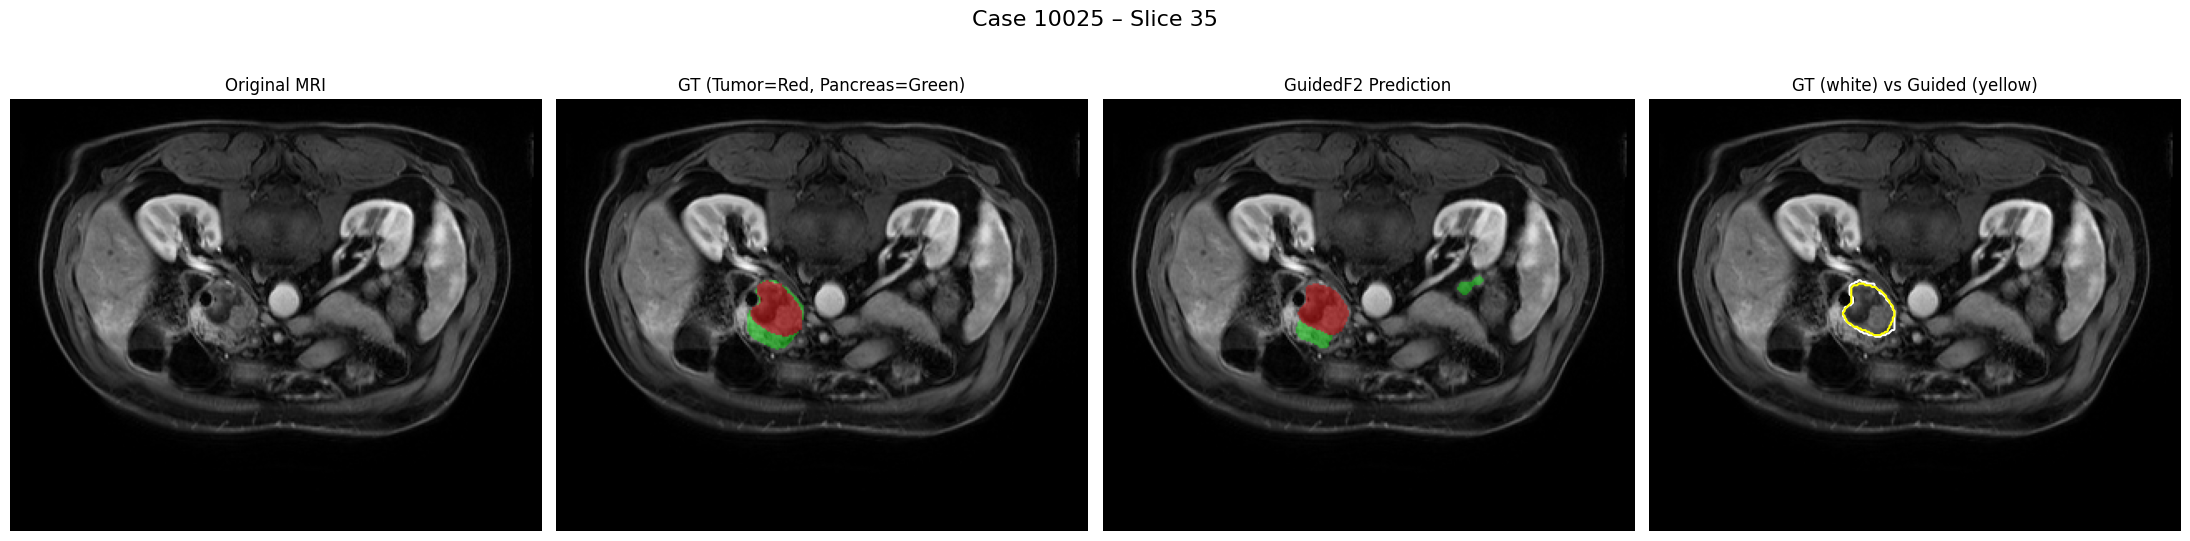

Tumor Metrics:
  Dice:   0.9012
  IoU:    0.8201
  HD95:   3.23 mm
  ASD:    0.78 mm
  NSD:    0.661

Pancreas Metrics:
  Dice:   0.8620
  IoU:    0.7575


========== CASE: 10105 ==========



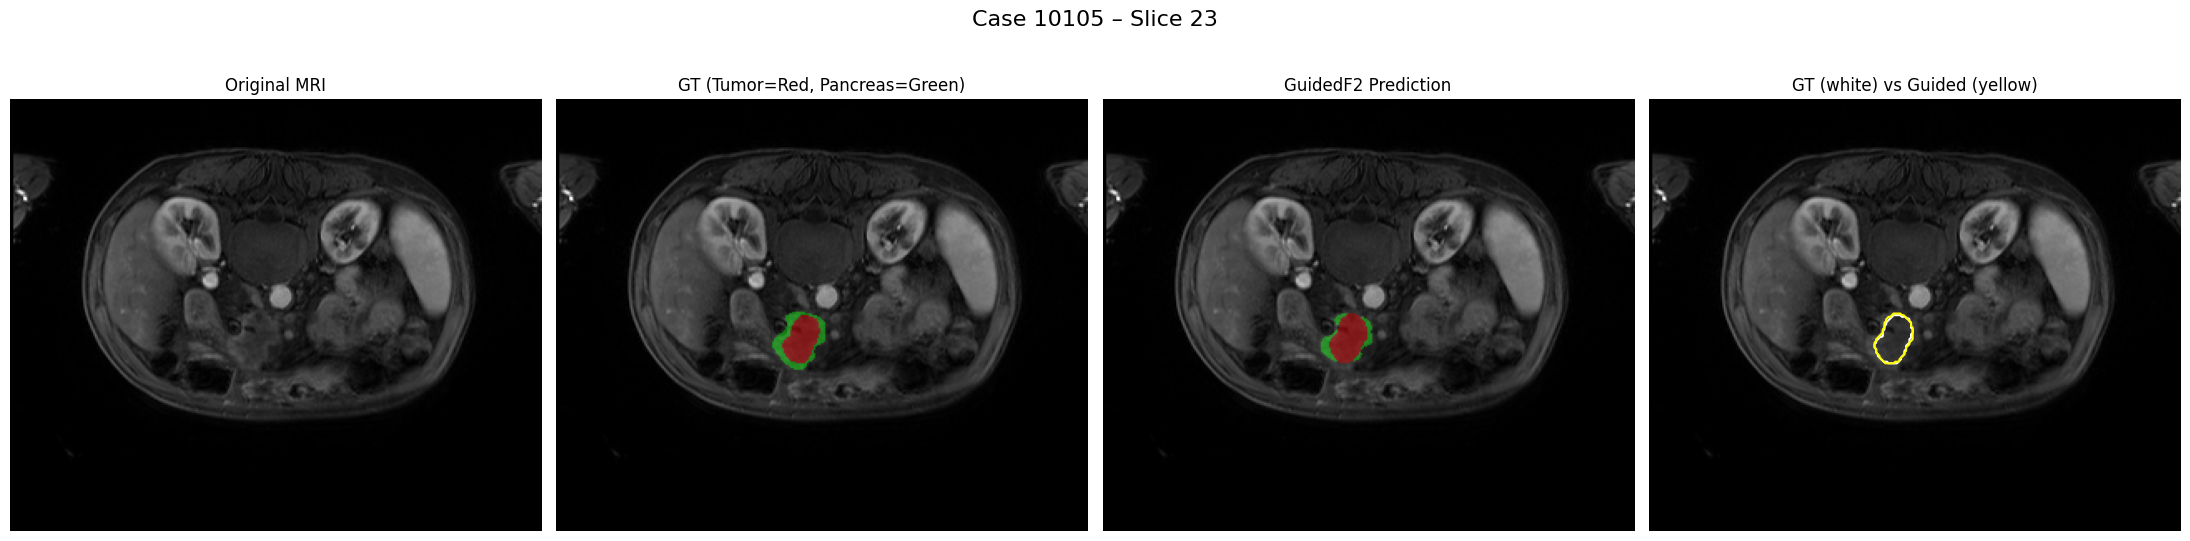

Tumor Metrics:
  Dice:   0.8691
  IoU:    0.7685
  HD95:   3.00 mm
  ASD:    0.63 mm
  NSD:    0.682

Pancreas Metrics:
  Dice:   0.7821
  IoU:    0.6422


========== CASE: 10100 ==========



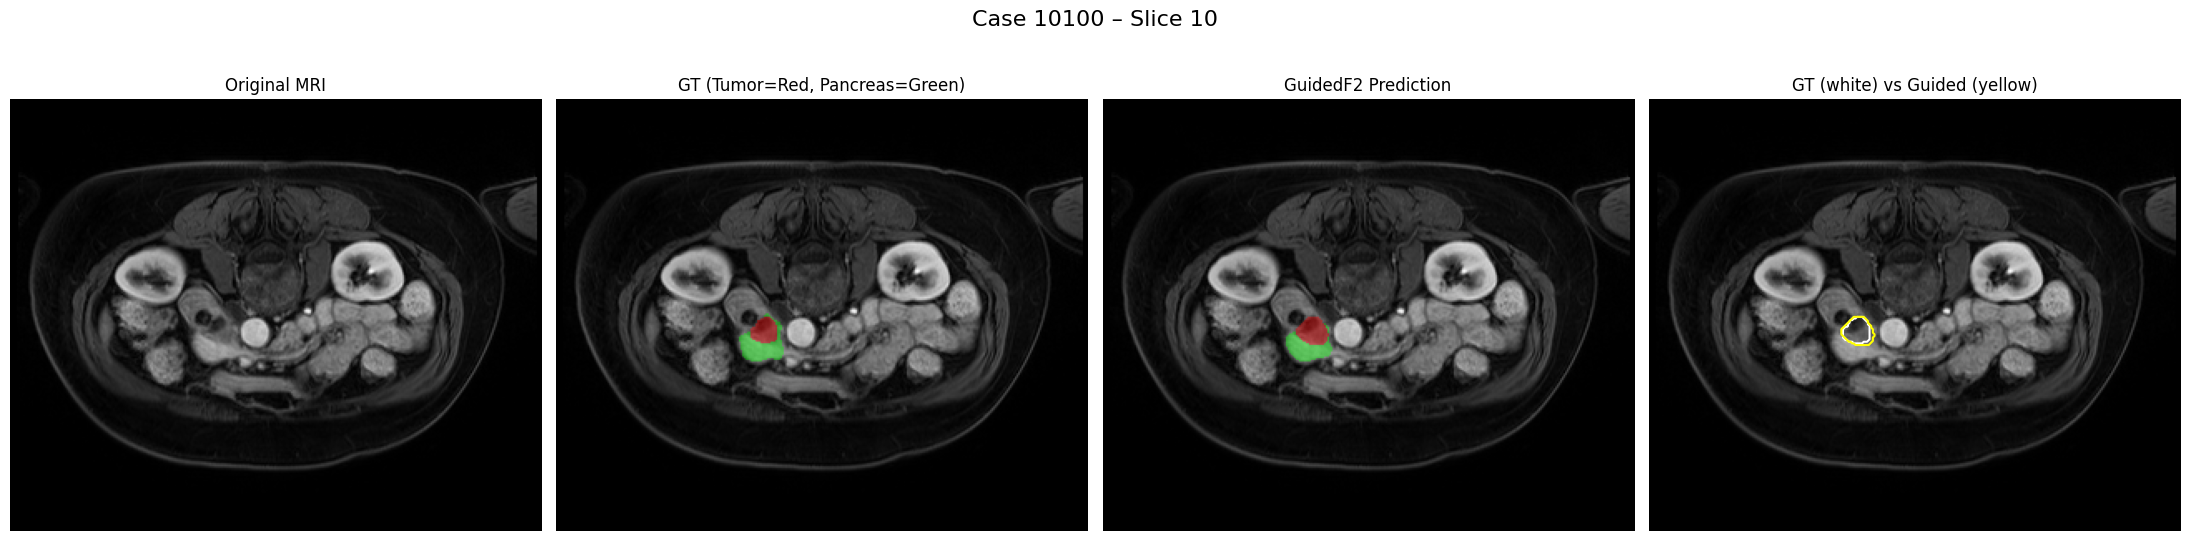

Tumor Metrics:
  Dice:   0.8363
  IoU:    0.7186
  HD95:   2.38 mm
  ASD:    0.46 mm
  NSD:    0.749

Pancreas Metrics:
  Dice:   0.9101
  IoU:    0.8351


========== CASE: 10011 ==========



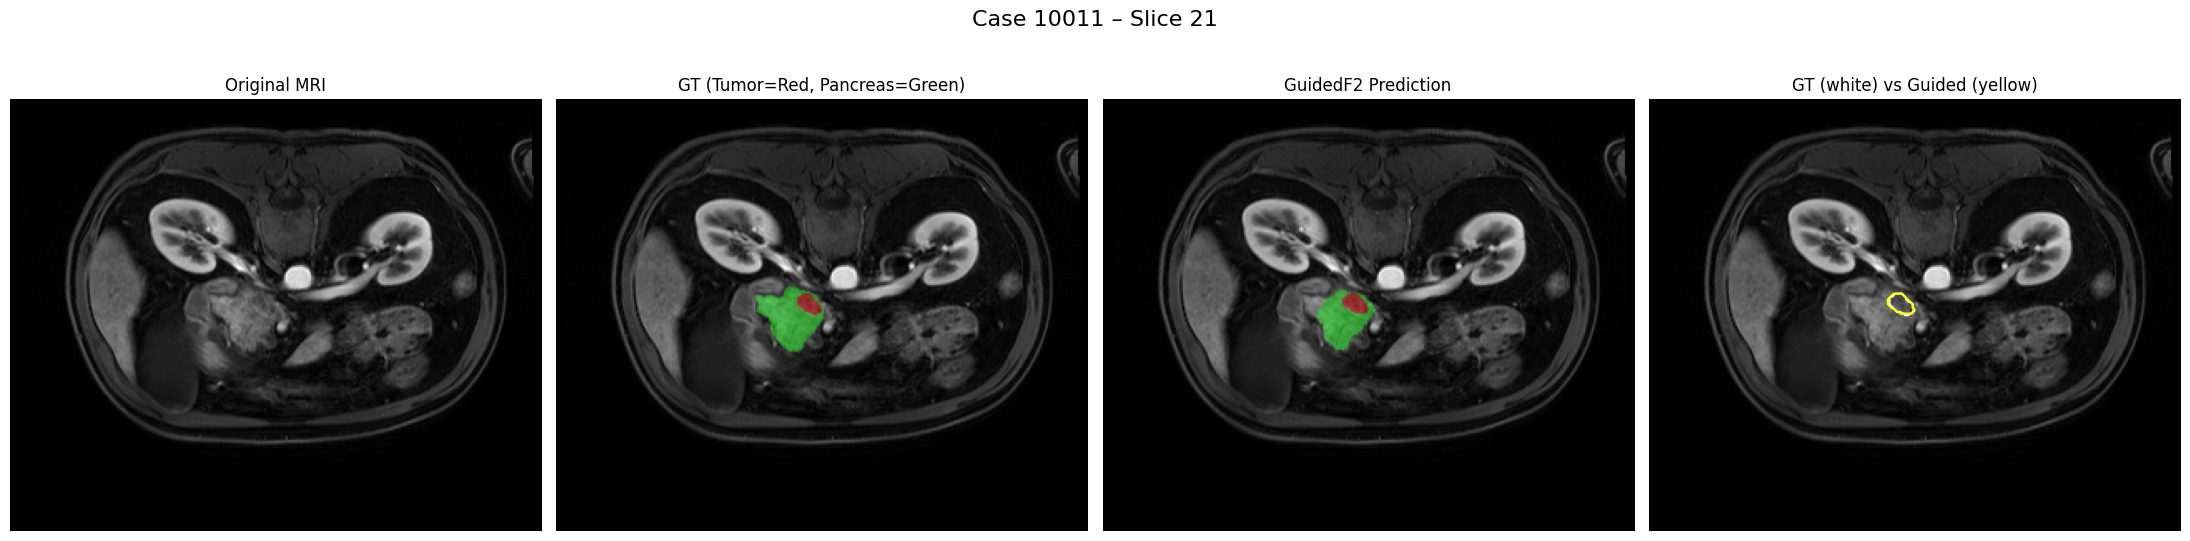

Tumor Metrics:
  Dice:   0.9074
  IoU:    0.8304
  HD95:   1.19 mm
  ASD:    0.20 mm
  NSD:    0.851

Pancreas Metrics:
  Dice:   0.9088
  IoU:    0.8329


========== CASE: 10047 ==========



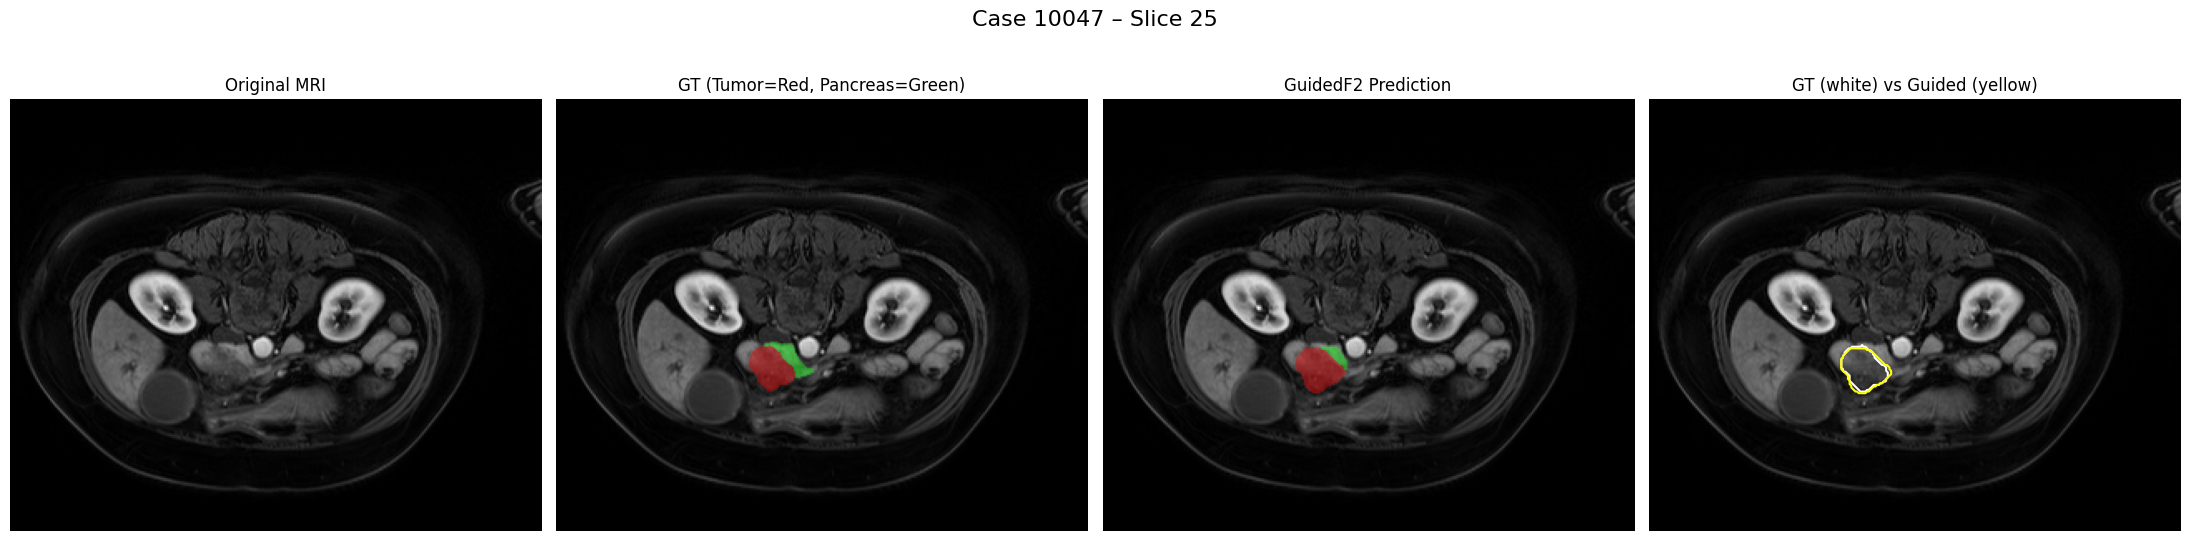

Tumor Metrics:
  Dice:   0.8689
  IoU:    0.7683
  HD95:   3.23 mm
  ASD:    0.74 mm
  NSD:    0.645

Pancreas Metrics:
  Dice:   0.8123
  IoU:    0.6839



In [16]:
import random
cases = random.sample(df_clean["case"].unique().tolist(), 5)
visualize_cases(cases)


In [17]:
import pandas as pd
from pathlib import Path
import numpy as np
import SimpleITK as sitk
import matplotlib.pyplot as plt

# paths (same as before)
NNUNET_RAW     = r"E:\nnUNet_raw"
NNUNET_RESULTS = r"E:\nnUNet_results"
DATASET_NAME   = "Dataset110_PANTHER_T1"

IMG_DIR   = Path(NNUNET_RAW) / DATASET_NAME / "imagesTr"
GT_DIR    = Path(NNUNET_RAW) / DATASET_NAME / "labelsTr"
OLD_F2_DIR      = Path(NNUNET_RESULTS) / "predictions_fold2"
GUIDED_TUMOR_DIR = Path(NNUNET_RESULTS) / "cmp_hybrid_GT" / "chooser_oldF2_newF2_guided_components"

PER_CASE_CSV = Path(NNUNET_RESULTS) / "quant_full_metrics" / DATASET_NAME / "per_instance_metrics_cleaned.csv"
df = pd.read_csv(PER_CASE_CSV)

# only guidedF2 tumour rows
g_tumor = df[(df["model"] == "guidedF2") & (df["class_name"] == "tumor")].copy()

# sort by Dice
g_tumor = g_tumor.sort_values("dice", ascending=False).reset_index(drop=True)

def stem_from_case(case_name):
    s = str(case_name)
    if s.endswith(".nii.gz"):
        s = s[:-7]
    elif s.endswith(".nii"):
        s = s[:-4]
    return s

def get_case_sets(n=3):
    """Return lists of case ids (stems) for best/mid/worst guidedF2 tumour Dice."""
    best = g_tumor.head(n)
    mid  = g_tumor.iloc[len(g_tumor)//2 - n//2 : len(g_tumor)//2 + (n - n//2)]
    worst = g_tumor.tail(n)

    best_cases  = [(stem_from_case(r.case), r) for _, r in best.iterrows()]
    mid_cases   = [(stem_from_case(r.case), r) for _, r in mid.iterrows()]
    worst_cases = [(stem_from_case(r.case), r) for _, r in worst.iterrows()]
    return best_cases, mid_cases, worst_cases

best_cases, mid_cases, worst_cases = get_case_sets(n=3)
best_cases[:2], mid_cases[:1], worst_cases[:2]


([('10016',
   case                         10016
   model                     guidedF2
   class_id                         1
   class_name                   tumor
   tp                           45391
   fp                            3304
   fn                            2889
   dice                      0.936138
   iou                       0.879943
   precision                 0.932149
   recall                    0.940162
   f1                        0.936138
   hd95_mm                        3.0
   asd_mm                    0.653544
   nsd                       0.703891
   boundary_error_mm         0.653544
   gt_vol_mm3            204247.03125
   pred_vol_mm3         206002.675781
   rvd                       0.008596
   ravd                      0.008596
   gt_empty                     False
   pred_empty                   False
   invalid_surface              False
   Name: 0, dtype: object),
  ('10007',
   case                         10007
   model                     guidedF

In [18]:
def load_nifti(path):
    img = sitk.ReadImage(str(path))
    arr = sitk.GetArrayFromImage(img)
    return img, arr

def choose_slice_with_max_tumor(gt_arr):
    tumor = (gt_arr == 1)
    per_slice = tumor.reshape(tumor.shape[0], -1).sum(axis=1)
    if per_slice.max() == 0:
        return gt_arr.shape[0] // 2
    return int(per_slice.argmax())

def build_guided_multiclass(old_arr, guided_tumor_arr):
    pancreas = (old_arr == 2)
    tumor    = guided_tumor_arr.astype(bool)
    seg = np.zeros_like(old_arr, dtype=np.uint8)
    seg[pancreas] = 2
    seg[tumor]    = 1
    return seg

def case_paths(stem):
    img_p = IMG_DIR / f"{stem}_0000.nii.gz"
    gt_p  = GT_DIR  / f"{stem}.nii.gz"
    old_p = OLD_F2_DIR / f"{stem}.nii.gz"
    gd_p  = GUIDED_TUMOR_DIR / f"{stem}.nii.gz"
    return img_p, gt_p, old_p, gd_p

def plot_prediction_triplet(stem, metrics_row, title_prefix=""):
    img_p, gt_p, old_p, gd_p = case_paths(stem)

    _, img = load_nifti(img_p)
    _, gt  = load_nifti(gt_p)
    _, old = load_nifti(old_p)
    _, gd_tumor = load_nifti(gd_p)

    guided_multi = build_guided_multiclass(old, gd_tumor)

    z = choose_slice_with_max_tumor(gt)

    sl_img = img[z]
    sl_gt  = gt[z]
    sl_pr  = guided_multi[z]

    gt_t = (sl_gt == 1); gt_p = (sl_gt == 2)
    pr_t = (sl_pr == 1); pr_p = (sl_pr == 2)

    fig, axes = plt.subplots(1, 3, figsize=(15, 5))

    # original
    axes[0].imshow(sl_img, cmap="gray")
    axes[0].set_title(f"{title_prefix}Case {stem}\nOriginal")
    axes[0].axis("off")

    # GT
    axes[1].imshow(sl_img, cmap="gray")
    axes[1].contour(gt_p, levels=[0.5], colors="g", linewidths=1.5)
    axes[1].contour(gt_t, levels=[0.5], colors="r", linewidths=1.5)
    axes[1].set_title("Ground Truth\n(green=pancreas, red=tumor)")
    axes[1].axis("off")

    # Guided prediction
    axes[2].imshow(sl_img, cmap="gray")
    axes[2].contour(pr_p, levels=[0.5], colors="g", linewidths=1.5)
    axes[2].contour(pr_t, levels=[0.5], colors="r", linewidths=1.5)
    axes[2].set_title(
        "Guided F2 prediction\n"
        f"Tumor Dice={metrics_row['dice']:.3f}, IoU={metrics_row['iou']:.3f}"
    )
    axes[2].axis("off")

    plt.tight_layout()
    plt.show()

    print(f"TUMOR metrics (guidedF2, case {stem}):")
    print(f"  Dice = {metrics_row['dice']:.4f}")
    print(f"  IoU  = {metrics_row['iou']:.4f}")
    print(f"  HD95 = {metrics_row['hd95_mm']:.2f} mm")
    print(f"  ASD  = {metrics_row['asd_mm']:.2f} mm")
    print(f"  NSD  = {metrics_row['nsd']:.3f}")
    print()


=== BEST tumour Dice cases ===


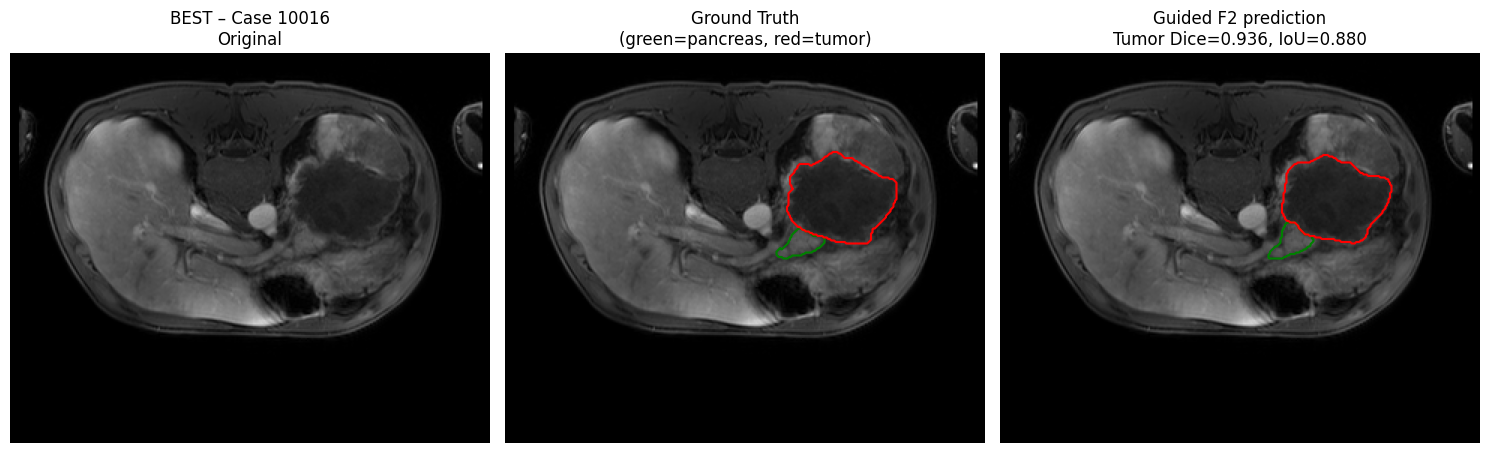

TUMOR metrics (guidedF2, case 10016):
  Dice = 0.9361
  IoU  = 0.8799
  HD95 = 3.00 mm
  ASD  = 0.65 mm
  NSD  = 0.704



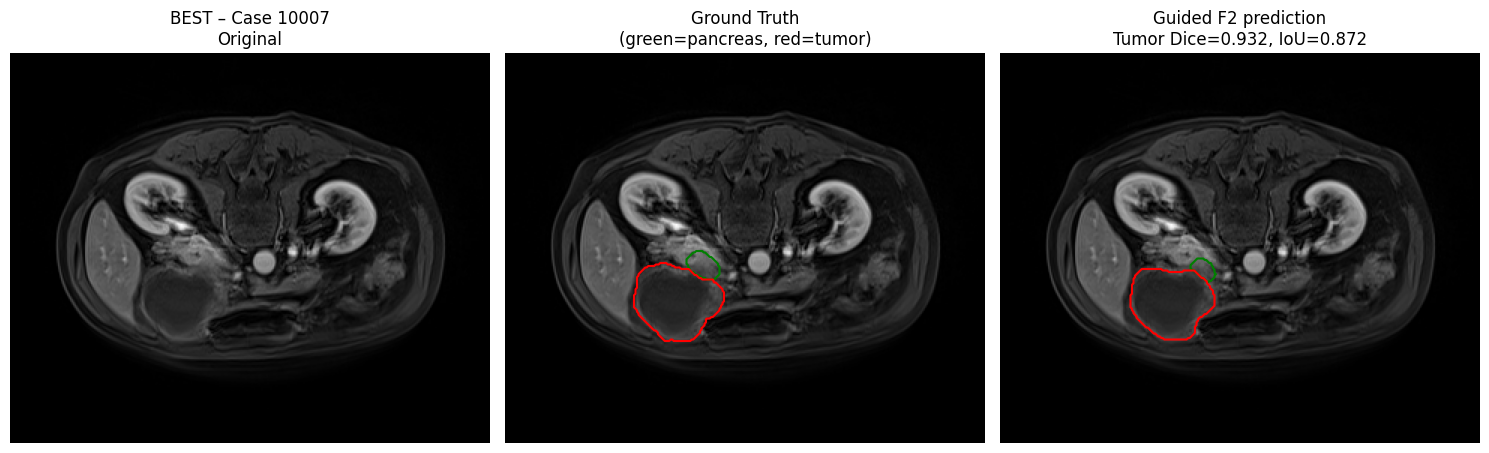

TUMOR metrics (guidedF2, case 10007):
  Dice = 0.9319
  IoU  = 0.8724
  HD95 = 3.00 mm
  ASD  = 0.57 mm
  NSD  = 0.717



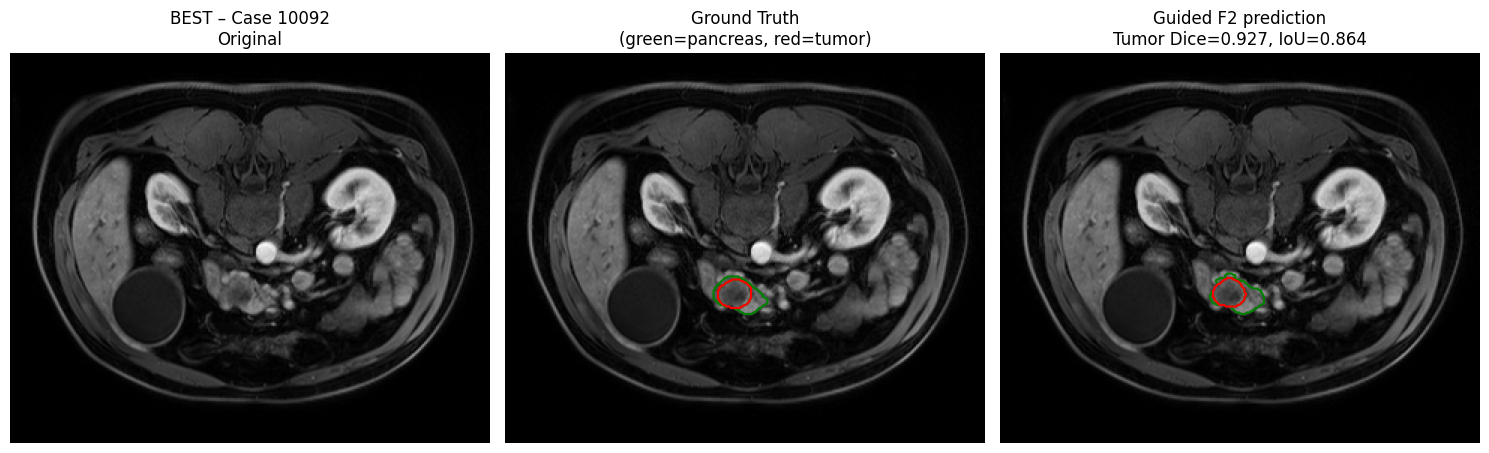

TUMOR metrics (guidedF2, case 10092):
  Dice = 0.9271
  IoU  = 0.8641
  HD95 = 1.19 mm
  ASD  = 0.26 mm
  NSD  = 0.811

=== MEDIAN tumour Dice cases ===


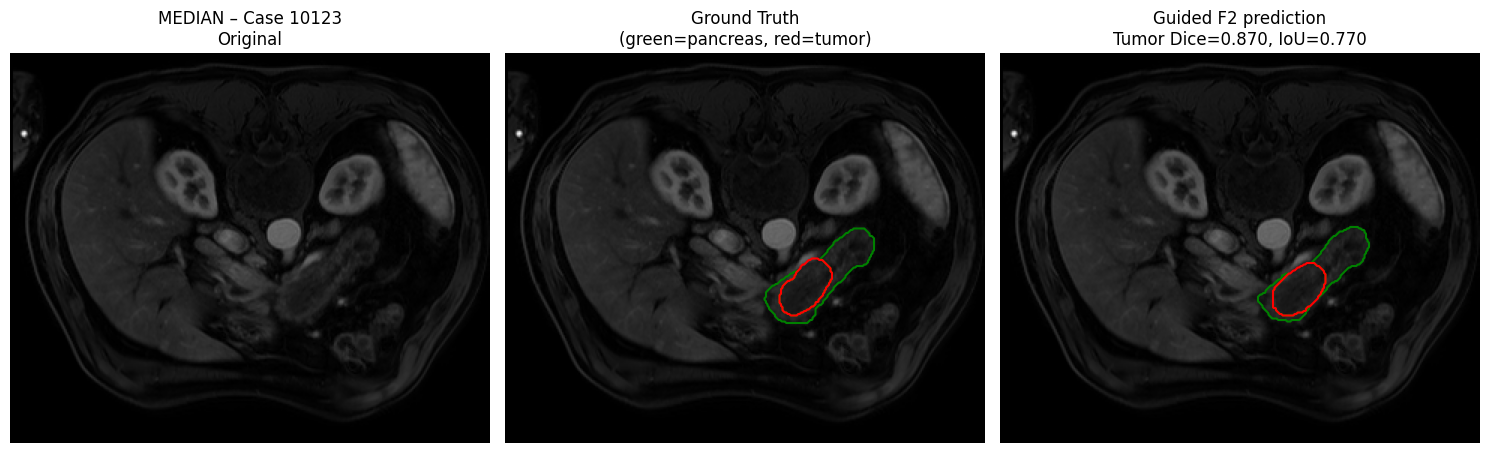

TUMOR metrics (guidedF2, case 10123):
  Dice = 0.8698
  IoU  = 0.7696
  HD95 = 3.00 mm
  ASD  = 0.76 mm
  NSD  = 0.662



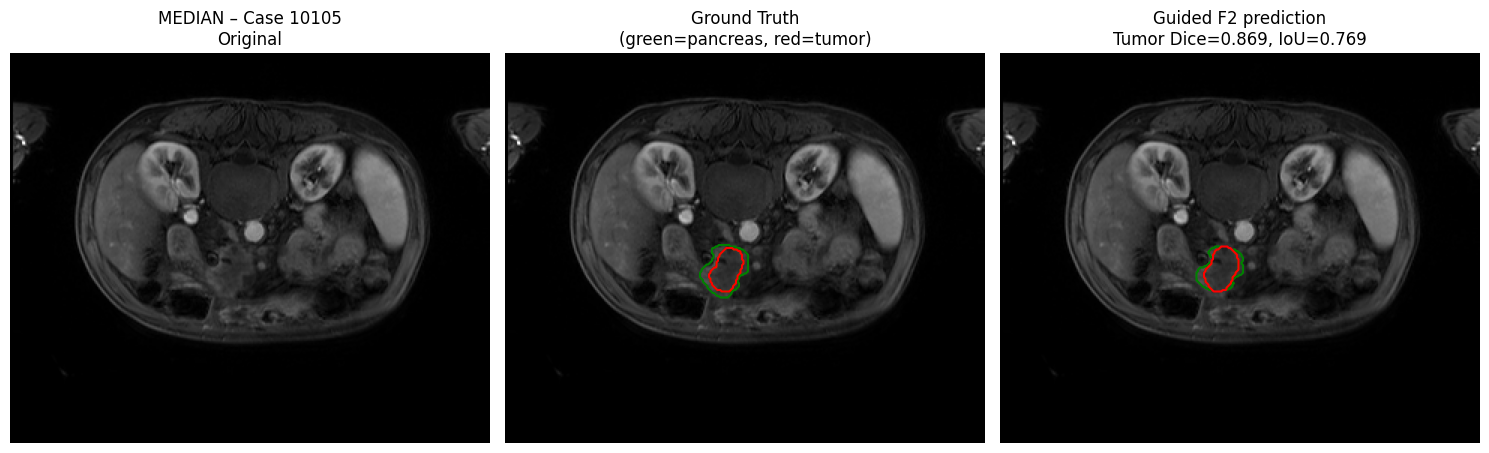

TUMOR metrics (guidedF2, case 10105):
  Dice = 0.8691
  IoU  = 0.7685
  HD95 = 3.00 mm
  ASD  = 0.63 mm
  NSD  = 0.682



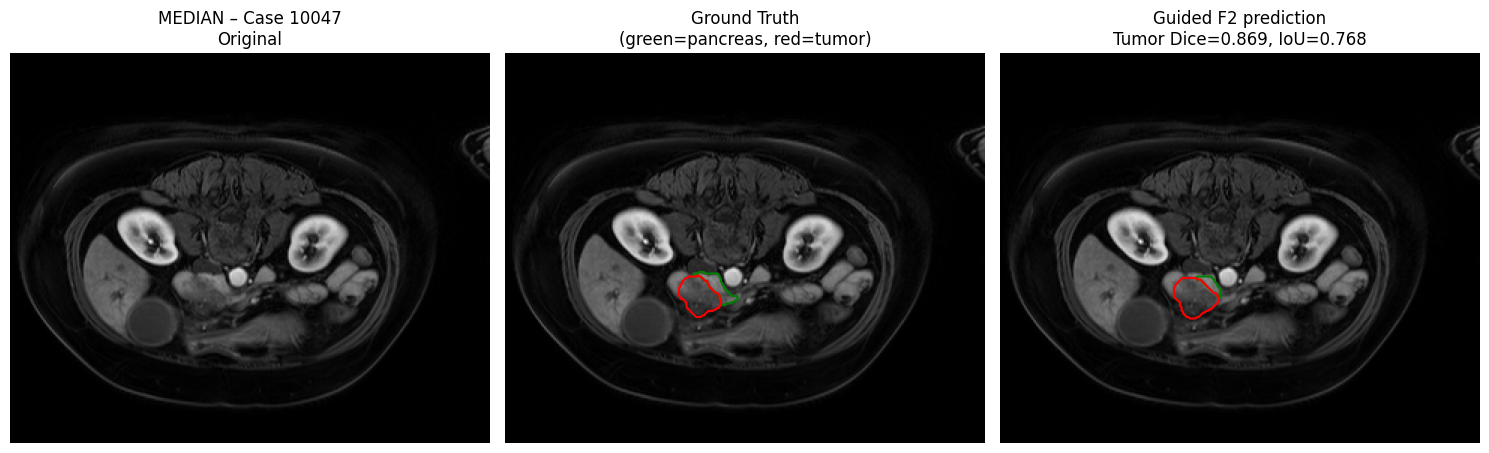

TUMOR metrics (guidedF2, case 10047):
  Dice = 0.8689
  IoU  = 0.7683
  HD95 = 3.23 mm
  ASD  = 0.74 mm
  NSD  = 0.645

=== WORST tumour Dice cases ===


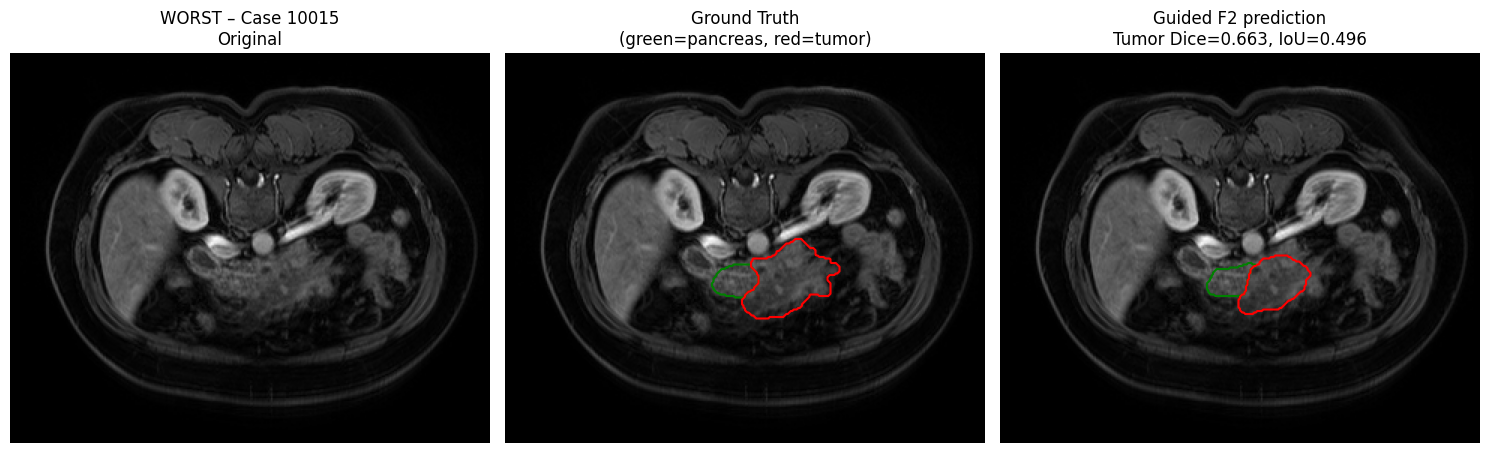

TUMOR metrics (guidedF2, case 10015):
  Dice = 0.6631
  IoU  = 0.4960
  HD95 = 19.39 mm
  ASD  = 4.81 mm
  NSD  = 0.408



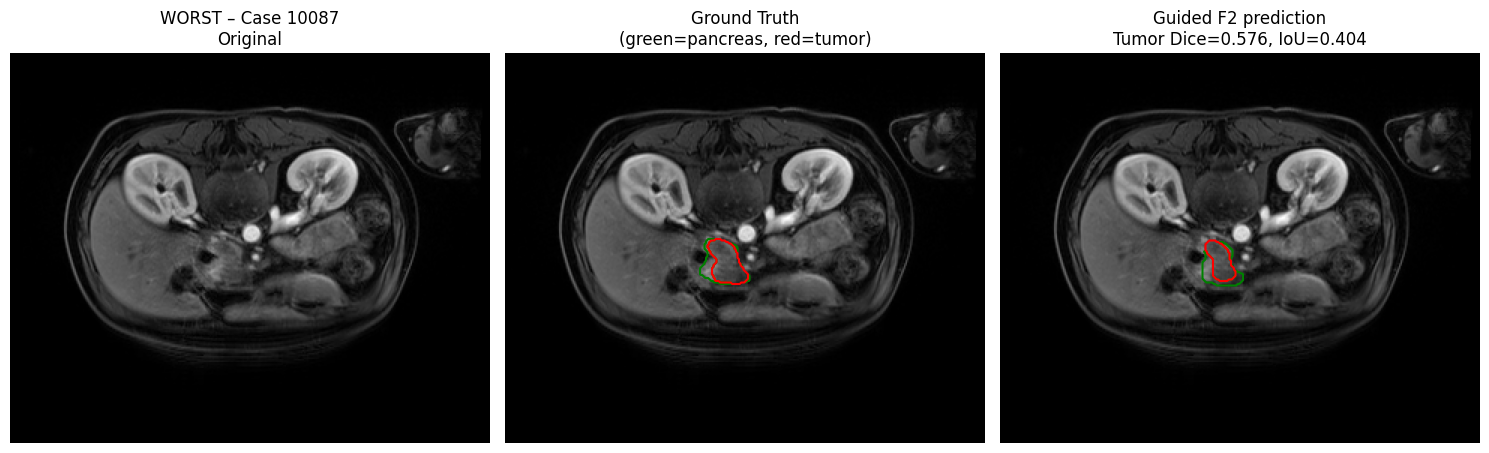

TUMOR metrics (guidedF2, case 10087):
  Dice = 0.5756
  IoU  = 0.4041
  HD95 = 8.09 mm
  ASD  = 2.44 mm
  NSD  = 0.425



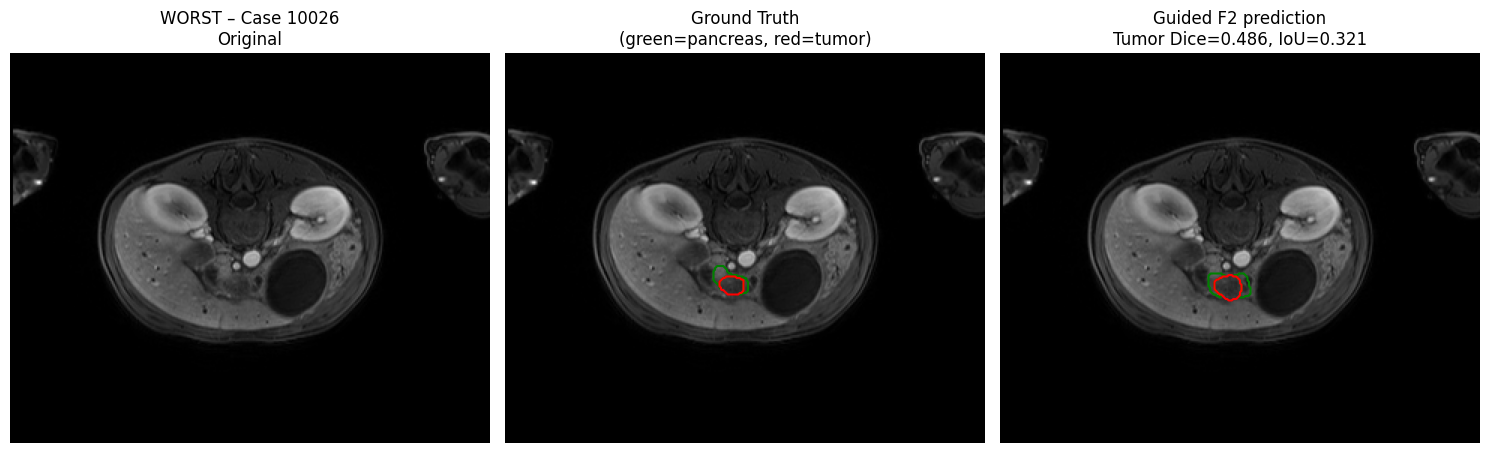

TUMOR metrics (guidedF2, case 10026):
  Dice = 0.4857
  IoU  = 0.3207
  HD95 = 50.03 mm
  ASD  = 19.61 mm
  NSD  = 0.307



In [19]:
print("=== BEST tumour Dice cases ===")
for stem, row in best_cases:
    plot_prediction_triplet(stem, row, title_prefix="BEST – ")

print("=== MEDIAN tumour Dice cases ===")
for stem, row in mid_cases:
    plot_prediction_triplet(stem, row, title_prefix="MEDIAN – ")

print("=== WORST tumour Dice cases ===")
for stem, row in worst_cases:
    plot_prediction_triplet(stem, row, title_prefix="WORST – ")


In [20]:
import numpy as np
import matplotlib.pyplot as plt
import SimpleITK as sitk
from pathlib import Path

# Directories (same as before)
NNUNET_RAW     = r"E:\nnUNet_raw"
NNUNET_RESULTS = r"E:\nnUNet_results"
DATASET_NAME   = "Dataset110_PANTHER_T1"

IMG_DIR   = Path(NNUNET_RAW) / DATASET_NAME / "imagesTr"
GT_DIR    = Path(NNUNET_RAW) / DATASET_NAME / "labelsTr"
OLD_F2    = Path(NNUNET_RESULTS) / "predictions_fold2"
NEW_F2    = Path(NNUNET_RESULTS) / "cmp_folds_GT" / "new" / "fold2"
GUIDED_F2 = Path(NNUNET_RESULTS) / "cmp_hybrid_GT" / "chooser_oldF2_newF2_guided_components"

# --- helper: load nifti
def load_arr(path):
    img = sitk.ReadImage(str(path))
    arr = sitk.GetArrayFromImage(img)
    return arr, img

# --- helper: pick max-tumor slice
def choose_slice(gt):
    t = (gt == 1)
    per = t.reshape(t.shape[0], -1).sum(axis=1)
    if per.max() == 0:
        return gt.shape[0]//2
    return int(per.argmax())

# --- build multi-class pred using guided
def build_multiclass(old_arr, guided_t):
    pancreas = (old_arr == 2)
    tumor = guided_t.astype(bool)
    out = np.zeros_like(old_arr, dtype=np.uint8)
    out[pancreas] = 2
    out[tumor] = 1
    return out

# --- error map function
def compute_error_map(gt, pred):
    gt_t   = (gt == 1)
    pred_t = (pred == 1)

    tp = gt_t & pred_t
    fn = gt_t & (~pred_t)
    fp = (~gt_t) & pred_t

    return tp, fn, fp

# --- visualization function
def plot_error_case(stem, row):
    print(f"\n=== ERROR ANALYSIS: Case {stem} ===")
    print(row)

    # paths
    img_p = IMG_DIR / f"{stem}_0000.nii.gz"
    gt_p  = GT_DIR  / f"{stem}.nii.gz"
    old_p = OLD_F2  / f"{stem}.nii.gz"
    new_p = NEW_F2  / f"{stem}.nii.gz"
    gd_p  = GUIDED_F2 / f"{stem}.nii.gz"

    # load
    img, _   = load_arr(img_p)
    gt, _    = load_arr(gt_p)
    old, _   = load_arr(old_p)
    new, _   = load_arr(new_p)
    gd_t, _  = load_arr(gd_p)

    guided = build_multiclass(old, gd_t)

    z = choose_slice(gt)
    sl_img = img[z]
    sl_gt  = gt[z]

    preds = {
        "oldF2": old[z],
        "newF2": new[z],
        "guidedF2": guided[z]
    }

    fig, axes = plt.subplots(3, 3, figsize=(18, 12))
    titles = ["oldF2", "newF2", "guidedF2"]

    # row 0 → original MRI + GT
    axes[0][0].imshow(sl_img, cmap="gray")
    axes[0][0].set_title("Original")
    axes[0][0].axis("off")

    axes[0][1].imshow(sl_img, cmap="gray")
    axes[0][1].contour(sl_gt==2, 1, colors="green")
    axes[0][1].contour(sl_gt==1, 1, colors="red")
    axes[0][1].set_title("Ground Truth")
    axes[0][1].axis("off")

    axes[0][2].axis("off")  # empty cell

    # row 1 & 2 for predictions + error maps
    for col, (name, pred) in enumerate(preds.items()):
        # contours
        axes[1][col].imshow(sl_img, cmap="gray")
        axes[1][col].contour(sl_gt==1, 1, colors="red", linewidths=1.3)
        axes[1][col].contour(pred==1, 1, colors="blue", linewidths=1.3)
        axes[1][col].set_title(f"{name}: GT (red) vs Pred (blue)")
        axes[1][col].axis("off")

        # error map
        tp, fn, fp = compute_error_map(sl_gt, pred)
        err_rgb = np.zeros((*tp.shape, 3), dtype=float)
        err_rgb[tp] = [0,1,0]   # green
        err_rgb[fn] = [1,0,0]   # red
        err_rgb[fp] = [0,0,1]   # blue

        axes[2][col].imshow(sl_img, cmap="gray")
        axes[2][col].imshow(err_rgb, alpha=0.5)
        axes[2][col].set_title(f"{name} Error Map\n(Green=TP, Red=FN, Blue=FP)")
        axes[2][col].axis("off")

    plt.tight_layout()
    plt.show()



=== ERROR ANALYSIS: Case 10015 ===
case                        10015
model                    guidedF2
class_id                        1
class_name                  tumor
tp                          14058
fp                           1646
fn                          12638
dice                     0.663113
iou                      0.496013
precision                0.895186
recall                   0.526596
f1                       0.663113
hd95_mm                  19.38599
asd_mm                   4.805834
nsd                      0.408336
boundary_error_mm        4.805834
gt_vol_mm3           112936.59375
pred_vol_mm3          66435.28125
rvd                     -0.411747
ravd                     0.411747
gt_empty                    False
pred_empty                  False
invalid_surface             False
Name: 89, dtype: object


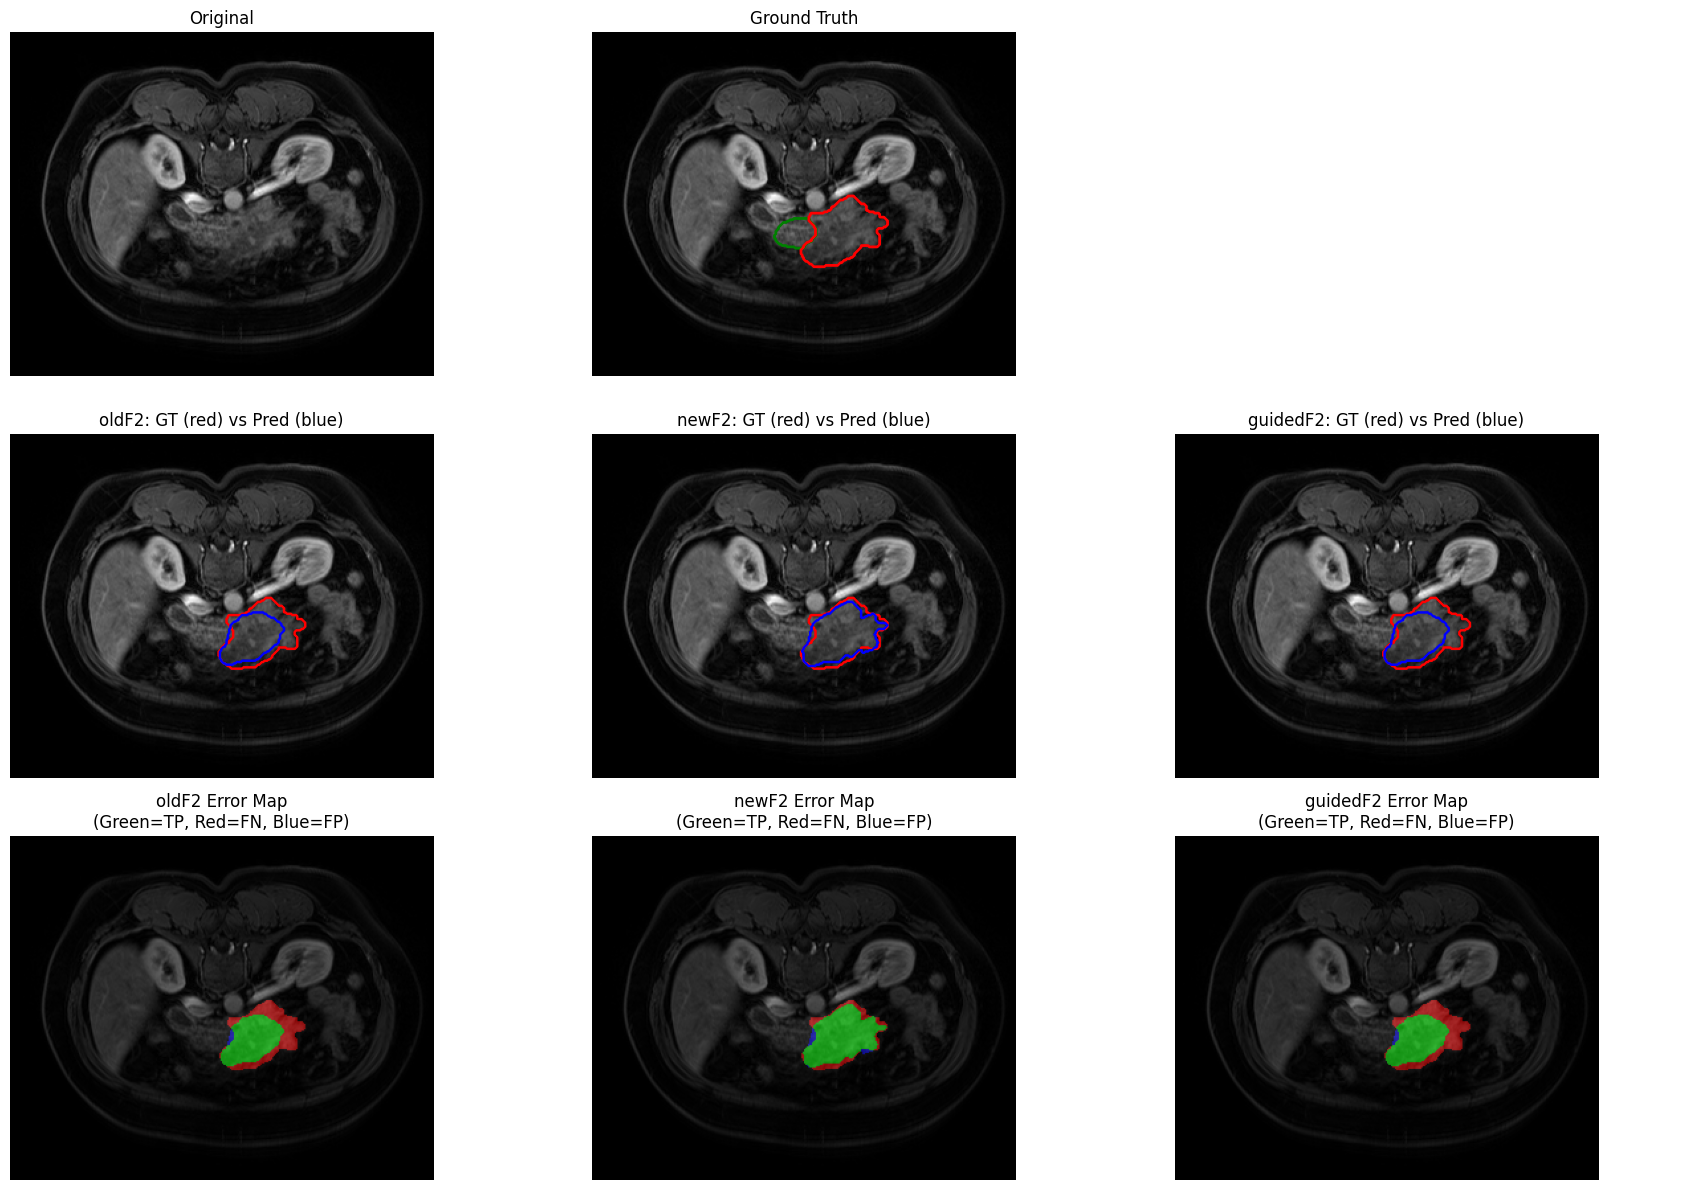


=== ERROR ANALYSIS: Case 10087 ===
case                        10087
model                    guidedF2
class_id                        1
class_name                  tumor
tp                           1130
fp                            155
fn                           1511
dice                      0.57565
iou                      0.404149
precision                0.879377
recall                   0.427868
f1                        0.57565
hd95_mm                  8.087413
asd_mm                   2.439391
nsd                      0.425012
boundary_error_mm        2.439391
gt_vol_mm3           11172.667969
pred_vol_mm3          5436.152344
rvd                     -0.513442
ravd                     0.513442
gt_empty                    False
pred_empty                  False
invalid_surface             False
Name: 90, dtype: object


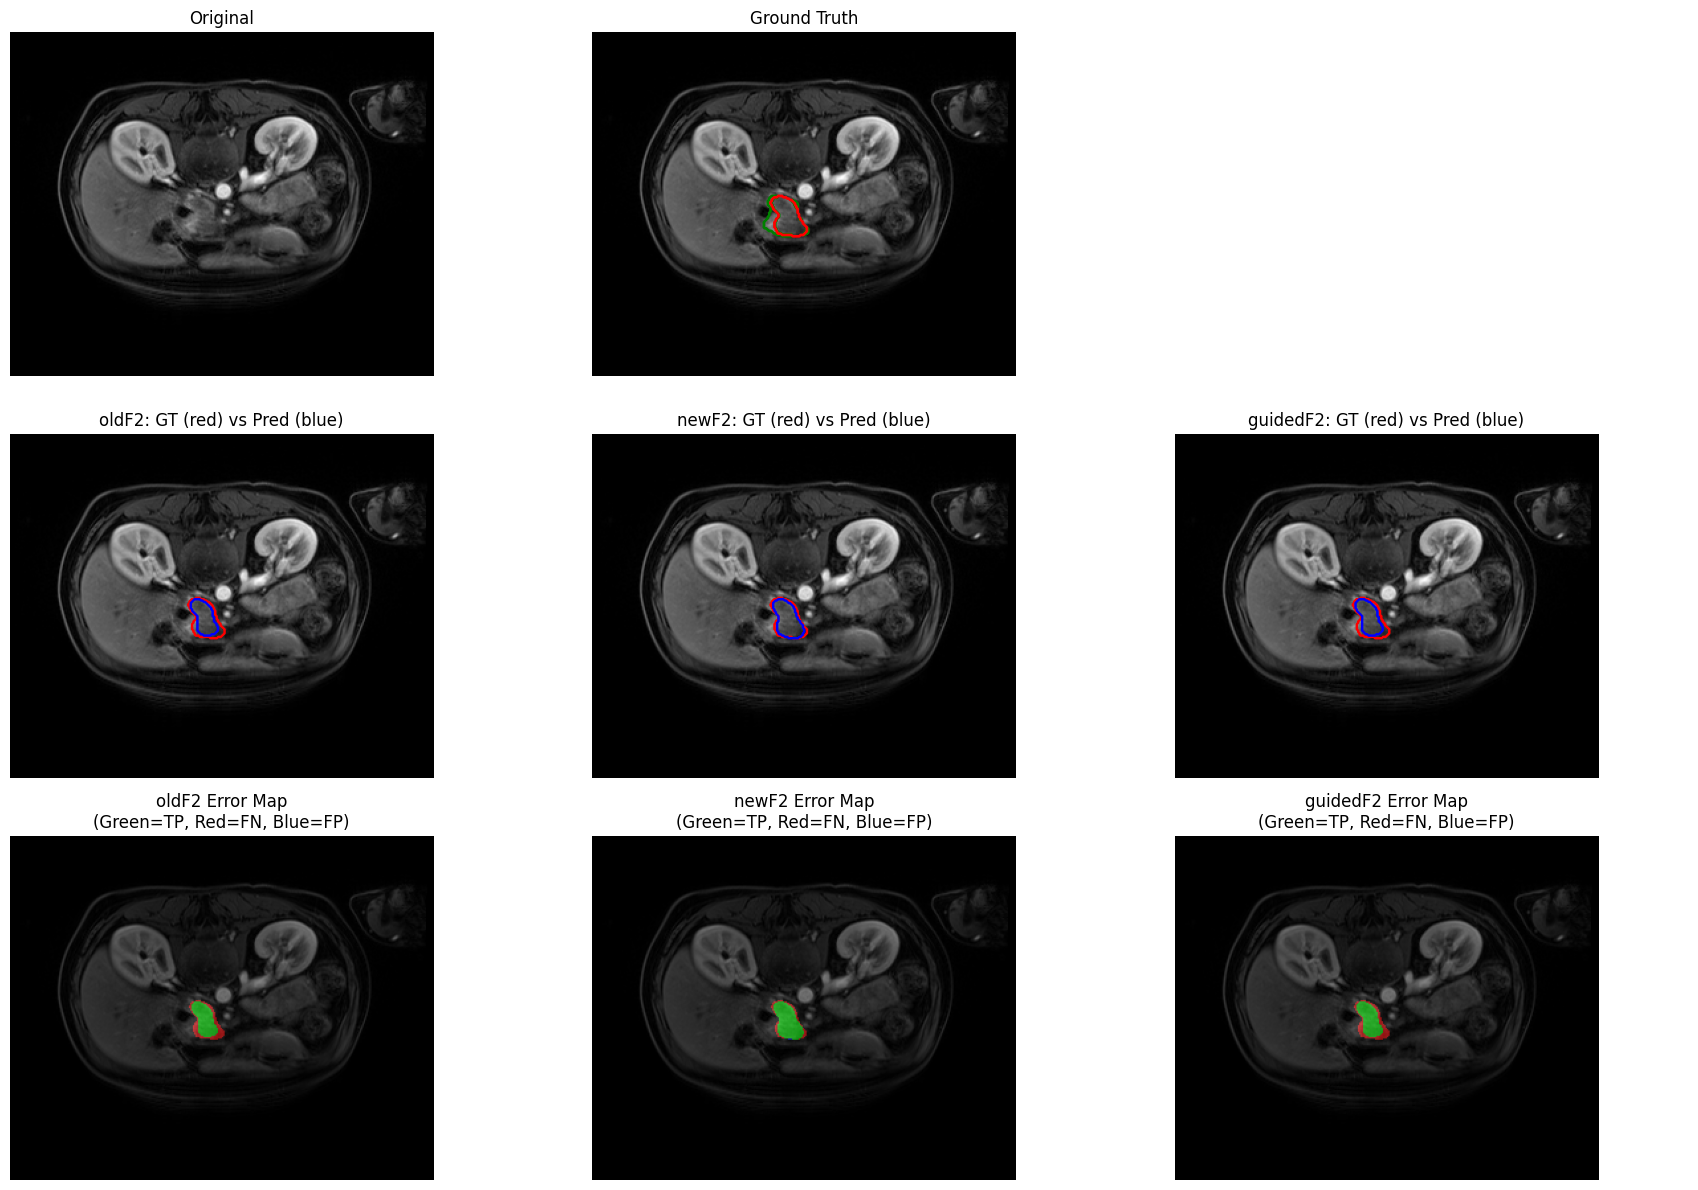


=== ERROR ANALYSIS: Case 10026 ===
case                        10026
model                    guidedF2
class_id                        1
class_name                  tumor
tp                            787
fp                           1600
fn                             67
dice                     0.485653
iou                      0.320701
precision                0.329703
recall                   0.921546
f1                       0.485653
hd95_mm                 50.025461
asd_mm                  19.606897
nsd                      0.306606
boundary_error_mm       19.606897
gt_vol_mm3            3612.820312
pred_vol_mm3         10098.128906
rvd                      1.795082
ravd                     1.795082
gt_empty                    False
pred_empty                  False
invalid_surface             False
Name: 91, dtype: object


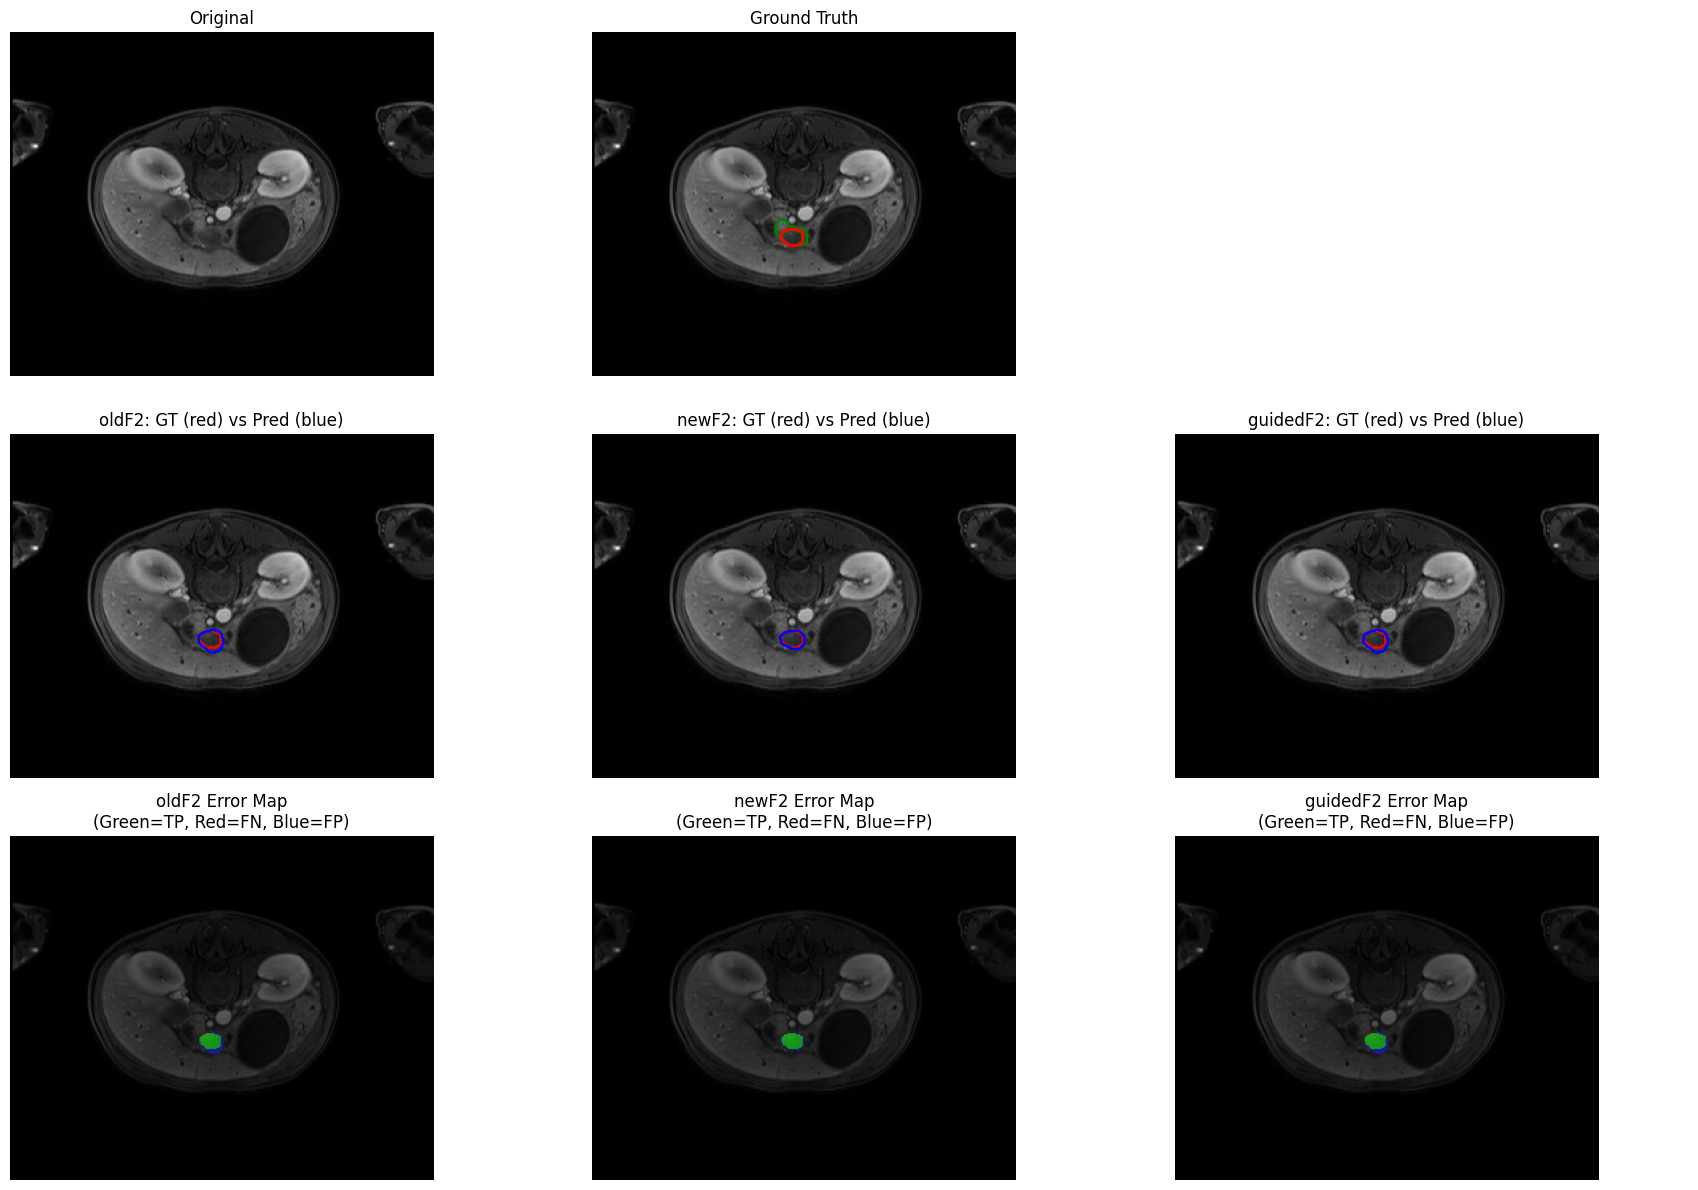

In [21]:
for stem, row in worst_cases:
    plot_error_case(stem, row)


Qualitative error analysis
Error maps (TP/FN/FP overlays) were generated for the three cases with the lowest tumor Dice scores. Across all cases, OldF2 (trained on labelled data only) consistently exhibited large false-negative regions, capturing only the high-contrast tumor core. NewF2 (semi-supervised) recovered substantially more tumor voxels but introduced mild boundary instability. GuidedF2 showed the most balanced behavior: it preserved the stable tumor core from OldF2 while selectively adopting NewF2 components that were well supported by the old prediction. This resulted in higher TP coverage, reduced FN extent, and minimal FP regions. The improvement was most pronounced in cases with medium-sized tumors, whereas all models struggled on extremely small or low-contrast tumors, where boundary ambiguity is inherent to the modality.